# Mixture sanity — do the mixed flow gauges read a mixture of district demand?

Three checks on data already on disk, over **every ok world of a study** (checks 1–2) and **every label
stack those worlds use** (check 3), so no conclusion rests on one hand-picked world. No engine code is
changed; nothing is written to disk.

The hypothesis under test: the gauges filling the mixed slots read the network's **storage / control
state** (pump switching, tank fill and draw), not a blend of district demands. Each check can falsify it.

| check | unit | question |
|---|---|---|
| 1 · raw series | one world (selector) | are the steps in the raw series, do they line up with pump/tank events, before or after the drift? |
| 2 · driver table | every world × placed flow gauge × window | which series does each gauge track best: a district demand, the total, a pump, a tank? |
| 3 · explainability | every label stack × flow gauge | how much of a gauge's profile does demand explain, and how much do pump/tank series add? |

In [1]:
%matplotlib inline
import warnings, logging, sys, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

REPO = next((p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
             if (p / "src" / "fedwater").is_dir()), None)
assert REPO is not None, "run this from inside the fedwater repo"
LAB_DIR = REPO / "notebooks" / "fedwater_lab_refactor"     # adjust to your layout
for p in (REPO / "src", LAB_DIR):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from fedwater.placement import mixture_probe as mp, signal_probe as sp, store
from fedwater.reporting import Atlas

warnings.filterwarnings("ignore")
logging.getLogger("kedro").setLevel(logging.WARNING)
pd.set_option("display.width", 230, "display.max_columns", 60, "display.max_rows", 200)
plt.rcParams.update({"figure.dpi": 110, "font.size": 8})

EXPERIMENTS = None              # None -> <project>/data/09_experiments
STUDY = None                    # None -> the latest study
ATLAS = Atlas(root=EXPERIMENTS)
STUDY = STUDY or ATLAS.studies()[1]
WORLDS = ATLAS.worlds(STUDY, ok_only=True)
print(f"study {STUDY}: {len(WORLDS)} ok worlds")
display(WORLDS.groupby(["network", "districting", "drift_district"], dropna=False).size()
        .rename("worlds").reset_index())

study ky72_districting_all_districts: 12 ok worlds


,network,districting,drift_district,worlds
0,ky72,fast_greedy,District_A,1
1,ky72,fast_greedy,District_B,1
2,ky72,fast_greedy,District_C,1
3,ky72,fast_greedy,District_D,1
4,ky72,girvan_newman,District_A,1
5,ky72,girvan_newman,District_B,1
6,ky72,girvan_newman,District_C,1
7,ky72,girvan_newman,District_D,1
8,ky72,spectral,District_A,1
9,ky72,spectral,District_B,1


### Shared helpers

Windows follow the pipeline exactly: a target world uses `verify_placement`'s rule (baseline = `init`;
final = from the later of the settle month and the drift's completion to the horizon); a probe world
uses `build_mixture`'s (`baseline_window`, `settled_window`, or `season_windows` with seasonality on).
Flows are read **raw, in `.inp` orientation** — no per-window sign alignment anywhere in this notebook.
A tank's net inflow is the signed sum of the flows on its incident links (into the tank positive).

In [2]:
FLOW = "flow"


def target_probe(w, with_pressures=False):
    # The world's own series as a Probe, built the way `verify_placement` builds it.
    sch = w.catalog.load("gt_drift_schedule")
    if sch is None or not len(sch):
        return None
    tgt = str(sch.sort_values("drift_month")["district"].iloc[0])
    dy = w.catalog.load("districts")
    return sp.Probe(districts=dy["districts"], assets=dy.get("assets") or {},
                    demand=w.catalog.load("demand_series"),
                    pressures=w.catalog.load("pressures") if with_pressures else pd.DataFrame(),
                    flows=w.catalog.load("flows"), schedule=sch, time=w.params["time"],
                    params={"patterns": w.params["patterns"]}, drift={"tgt_district": tgt},
                    label=w.sim_hash)


def target_windows(P, settle, patterns):
    # (init, final) step windows -- `placement.verify.verify_placement`'s rule.
    sm, n = P.steps_month, int(P.time["n_months"])
    if float((patterns or {}).get("seasonality_scale", 0.0)) > 0:
        return mp.season_windows(P, pad=int(settle["pad"]))
    final0 = int(P.phases()["final"][0])
    try:
        s_lo, _ = mp.settled_window(P, ref_months=int(settle["ref_months"]),
                                    slack=float(settle["slack"]), pad=int(settle["pad"]),
                                    min_months=0)
        start = max(s_lo // sm, final0)
    except ValueError:
        start = final0
    need = int(settle.get("min_months", 3))
    if n - start < need:
        raise ValueError(f"unsettled: {n - start} settled month(s) after month {final0}, {need} needed")
    return mp.baseline_window(P), (start * sm, n * sm)


def stack_windows(P, settle):
    # (baseline, settled) step windows -- `build_mixture`'s rule.
    if float((P.params.get("patterns") or {}).get("seasonality_scale", 0.0)) > 0:
        return mp.season_windows(P, pad=int(settle["pad"]))
    return mp.baseline_window(P), mp.settled_window(
        P, ref_months=int(settle["ref_months"]), slack=float(settle["slack"]),
        pad=int(settle["pad"]))


def storage_map(wn, flow_cols):
    # pumps -> [pump], tanks -> [(link, +1 into tank / -1 out of it)], restricted to logged links.
    cols = set(flow_cols)
    pumps = [p for p in wn.pump_name_list if p in cols]
    tanks = {}
    for t in wn.tank_name_list:
        inc = [(ln, 1.0 if wn.get_link(ln).end_node_name == t else -1.0)
               for ln in wn.get_links_for_node(t) if ln in cols]
        if inc:
            tanks[t] = inc
    return pumps, tanks


def storage_series(P, pumps, tanks):
    # step x driver frame: pump flows and tank net inflows, raw.
    X = {f"pump:{p}": P.flows[p].to_numpy(float) for p in pumps}
    for t, inc in tanks.items():
        X[f"tank:{t}"] = np.sum([s * P.flows[ln].to_numpy(float) for ln, s in inc], axis=0)
    return pd.DataFrame(X, index=P.flows.index)


def fold(values, P, lo, hi):
    # (m, T) weekly profile of a step x m array over [lo, hi); (0, T) when m == 0.
    v = np.asarray(values, float)[lo:hi]
    T = 7 * P.steps_day
    if v.ndim == 1:
        v = v[:, None]
    if v.shape[1] == 0:
        return np.empty((0, T))
    return np.atleast_2d(sp.weekly_profile(v, P.steps_day, step0=lo))


def corr_rows(A, B):
    # (n, T) x (m, T) -> (n, m) Pearson r; a constant row gives NaN, not 0.
    sa, sb = A.std(axis=1), B.std(axis=1)
    r = sp._corr_rows(A, B)
    r[sa < 1e-12, :] = np.nan
    r[:, sb < 1e-12] = np.nan
    return r


def opposite_share(q):
    # Share of steps whose flow sign is opposite to the window-mean sign (|q| above a relative floor).
    q = np.asarray(q, float)
    m = q.mean()
    floor = 1e-6 * max(np.abs(q).max(), 1e-12)
    return float(((np.sign(q) == -np.sign(m)) & (np.abs(q) > floor)).mean()) if m != 0 else np.nan

## Check 1 — raw series around the drift (one world at a time)

For the selected world: every placed **flow** gauge in native units, `.inp` orientation, over the last 14
days of the baseline window (left) and the first 14 days of the settled window (right). Pure slots solid,
mixed slots dashed; the district's own demand on the twin axis (black, thin). Grey verticals mark **pump
status changes** (a pump's flow crossing a relative floor). The bottom row is the storage state: tank
levels (tank pressure, if tanks are logged in `pressures`; otherwise cumulative net inflow, i.e. relative
volume) with total pump flow on the twin axis.

| what to look for | reading |
|---|---|
| steps in the raw series that coincide with the grey verticals or tank turning points | the gauge reads control / storage state |
| a mixed gauge that follows its district demand smoothly | the gauge reads demand — the hypothesis fails for it |
| switching already present on the left (baseline) | the behaviour is structural, not created by the drift |
| a mixed gauge whose sign alternates within a day | fill/draw — the mechanism behind the reversals |

The `.inp` controls of the network are printed once per network above the figure.

In [3]:
SHOW_DAYS = 14
_controls_shown = set()


def raw_series(w):
    if w.row["network"] not in _controls_shown:
        wn = w.network_model
        ctr = list(wn.controls())
        print(f"{w.row['network']}: {len(ctr)} controls, {len(wn.pump_name_list)} pumps, "
              f"{len(wn.tank_name_list)} tanks")
        for name, c in ctr[:40]:
            print(f"  {name}: {c}")
        if len(ctr) > 40:
            print(f"  ... {len(ctr) - 40} more")
        _controls_shown.add(w.row["network"])
    P = target_probe(w, with_pressures=True)
    if P is None:
        print("no drift in this world"); return
    try:
        (i0, i1), (f0, f1) = target_windows(P, w.params["sensor_placement"]["probe"]["settle"],
                                            w.params["patterns"])
    except ValueError as exc:
        print(exc); return
    span = SHOW_DAYS * P.steps_day
    wins = {"baseline (last %d d)" % SHOW_DAYS: (max(i0, i1 - span), i1),
            "settled (first %d d)" % SHOW_DAYS: (f0, min(f1, f0 + span))}
    PL = w.catalog.load("sensor_placement")
    PL = PL[PL["kind"] == FLOW]
    pumps, tanks = storage_map(w.network_model, P.flows.columns)
    hours = float(P.time["resolution_h"])
    names = P.names
    fig, axes = plt.subplots(len(names) + 1, 2, figsize=(16, 2.5 * (len(names) + 1)),
                             squeeze=False, sharex="col")
    for c, (title, (lo, hi)) in enumerate(wins.items()):
        t = (np.arange(lo, hi) - lo) * hours / 24.0
        edges = []
        for p in pumps:
            q = P.flows[p].to_numpy(float)[lo:hi]
            s = np.abs(q) > 1e-6 * max(np.abs(P.flows[p].to_numpy(float)).max(), 1e-12)
            edges += list(np.where(np.diff(s.astype(int)) != 0)[0] + 1)
        for r, d in enumerate(names):
            ax = axes[r][c]
            for _, g in PL[PL["district"] == d].iterrows():
                ls = "-" if g["slot_class"] == "pure" else "--"
                ax.plot(t, P.flows[str(g["element"])].to_numpy(float)[lo:hi], ls, lw=1,
                        label=f"{g['sensor']} ({g['slot_class']})")
            ax2 = ax.twinx()
            ax2.plot(t, P.district_demand[d].to_numpy(float)[lo:hi], color="k", lw=0.6)
            ax2.set_ylabel("demand", fontsize=7)
            for e in edges:
                ax.axvline(t[e], color="0.6", lw=0.4, alpha=0.6)
            ax.axhline(0, color="0.3", lw=0.5)
            ax.set_title(f"{d} — {title}", fontsize=8)
            ax.set_ylabel("flow")
            ax.legend(fontsize=6, ncol=2, loc="upper left")
        ax = axes[-1][c]
        for tk in tanks:
            if tk in P.pressures.columns:
                ax.plot(t, P.pressures[tk].to_numpy(float)[lo:hi], lw=1, label=f"{tk} level")
            else:
                inflow = storage_series(P, [], {tk: tanks[tk]}).iloc[:, 0].to_numpy()
                ax.plot(t, np.cumsum(inflow[lo:hi]) * hours * 3600, lw=1,
                        label=f"{tk} rel. volume")
        if pumps:
            ax2 = ax.twinx()
            ax2.plot(t, P.flows[pumps].to_numpy(float)[lo:hi].sum(axis=1), color="k", lw=0.6)
            ax2.set_ylabel("pump flow", fontsize=7)
        for e in edges:
            ax.axvline(t[e], color="0.6", lw=0.4, alpha=0.6)
        ax.set_title(f"storage — {title}", fontsize=8)
        ax.set_xlabel("day in window")
        if tanks:
            ax.legend(fontsize=6, loc="upper left")
    fig.suptitle(f"{w.row['network']}/{w.row['districting']} — drift {P.drift['tgt_district']} "
                 f"— world {w.sim_hash[:8]}", fontsize=9)
    fig.tight_layout(); plt.show()


SEL = ATLAS.selector(study=STUDY)
display(SEL)
SEL.show(raw_series);

Output()

## Check 2 — driver table (every world, every placed flow gauge, both windows)

Per world, window $W\in\{\text{init},\text{final}\}$ and placed flow gauge $s$, with $Q_s$ its native
weekly profile on $W$ and $x$ ranging over the candidate drivers — the $K$ district demand profiles, the
network total $\sum_k D_k$, each pump's flow, each tank's net inflow (same window, same fold):

| column | measures | definition | range · expect if the hypothesis holds |
|---|---|---|---|
| `r_own` | tracks its own district | $\lvert r(Q_s, D_{\mathrm{home}})\rvert$ | [0,1] · pure ≈ 1, mixed low |
| `r_dem` | best demand-side driver | $\max_{x\in\{D_k,\sum D\}}\lvert r(Q_s,x)\rvert$ | [0,1] |
| `r_sto` | best storage-side driver | $\max_{x\in\{\text{pumps},\text{tanks}\}}\lvert r(Q_s,x)\rvert$ | [0,1] · mixed > `r_dem` |
| `best`, `best_kind` | which series it tracks best | $\arg\max_x \lvert r(Q_s,x)\rvert$ over all drivers; kind ∈ {district, total, pump, tank} | pure → district, mixed → pump/tank |
| `phi` | does the flow alternate direction | share of raw steps in $W$ whose sign is opposite to the window-mean sign | 0 for demand-fed links · > 0 for fill/draw |

$r$ is Pearson over the weekly profile, so sign is ignored (`|r|`) — an anti-phase tank link counts as
tracking the tank. **Caveat:** on a pump-fed network the drivers are collinear (tank inflow ≈ pump −
demand), so `best` can be ambiguous between total, pump and tank; check 3 handles that with a nested
regression. A network with no pumps and no tanks gets `r_sto = NaN` and is a demand-only reference.

  check 2: 12/12 worlds


**Which kind of series each placed gauge tracks best** (share of rows)

district  pump  tank   n
network districting   window slot_class                          
ky72    fast_greedy   final  mixed           0.00  0.19  0.81  32
                             pure            1.00  0.00  0.00  32
                      init   mixed           0.00  0.12  0.88  32
                             pure            1.00  0.00  0.00  32
        girvan_newman final  mixed           0.09  0.16  0.75  32
                             pure            1.00  0.00  0.00  32
                      init   mixed           0.00  0.25  0.75  32
                             pure            1.00  0.00  0.00  32
        spectral      final  mixed           0.25  0.19  0.56  32
                             pure            1.00  0.00  0.00  32
                      init   mixed           0.25  0.25  0.50  32
                             pure            1.00  0.00  0.00  32

**Medians**

r_own  r_dem  r_sto    phi
network districting   window slot_class                            
ky72    fast_greedy   final  mixed       0.464  0.498  0.966  0.412
                             pure        1.000  1.000  0.406  0.000
                      init   mixed       0.542  0.561  0.954  0.448
                             pure        1.000  1.000  0.462  0.000
        girvan_newman final  mixed       0.551  0.623  0.984  0.407
                             pure        1.000  1.000  0.531  0.000
                      init   mixed       0.517  0.607  0.953  0.335
                             pure        1.000  1.000  0.450  0.000
        spectral      final  mixed       0.595  0.630  0.974  0.289
                             pure        1.000  1.000  0.382  0.000
                      init   mixed       0.598  0.628  0.985  0.445
                             pure        1.000  1.000  0.429  0.000

**Same, by gauge** — a gauge placed in many worlds should behave consistently

worlds  r_own  r_dem  r_sto    phi best_kind
network districting   slot_class sensor  window                                              
ky72    fast_greedy   mixed      q_P-10  final        4  0.520  0.581  0.987  0.452      tank
                                         init         4  0.572  0.689  0.992  0.405      tank
                                 q_P-164 final        4  0.423  0.441  0.968  0.436      tank
                                         init         4  0.527  0.527  0.949  0.448      tank
                                 q_P-191 final        4  0.711  0.720  0.879  0.326      tank
                                         init         4  0.775  0.775  0.828  0.560      tank
                                 q_P-246 final        4  0.304  0.386  0.954  0.494      tank
                                         init         4  0.315  0.440  0.974  0.552      tank
                                 q_P-267 final        4  0.077  0.347  0.970  0.360      pump
                                         init         4  0.103  0.502  0.946  0.446      pump
                                 q_P-288 final        4  0.423  0.443  0.962  0.494      tank
                                         init         4  0.564  0.565  0.958  0.448      tank
                                 q_P-537 final        4  0.521  0.536  0.973  0.341      tank
                                         init         4  0.526  0.657  0.987  0.342      tank
                                 q_P-617 final        4  0.478  0.493  0.966  0.443      tank
                                         init         4  0.557  0.557  0.946  0.449      tank
                      pure       q_P-195 final        4  1.000  1.000  0.443  0.000  district
                                         init         4  1.000  1.000  0.460  0.000  district
                                 q_P-229 final        4  1.000  1.000  0.416  0.000  district
                                         init         4  1.000  1.000  0.520  0.000  district
                                 q_P-275 final        4  1.000  1.000  0.419  0.000  district
                                         init         4  1.000  1.000  0.523  0.000  district
                                 q_P-285 final        4  1.000  1.000  0.441  0.000  district
                                         init         4  1.000  1.000  0.459  0.000  district
                                 q_P-467 final        4  1.000  1.000  0.448  0.000  district
                                         init         4  1.000  1.000  0.457  0.000  district
                                 q_P-479 final        4  1.000  1.000  0.378  0.000  district
                                         init         4  1.000  1.000  0.465  0.000  district
                                 q_P-499 final        4  1.000  1.000  0.438  0.000  district
                                         init         4  1.000  1.000  0.455  0.000  district
                                 q_P-80  final        4  1.000  1.000  0.378  0.000  district
                                         init         4  1.000  1.000  0.464  0.000  district
        girvan_newman mixed      q_P-10  final        4  0.561  0.608  0.994  0.447      tank
                                         init         4  0.479  0.583  0.992  0.338      tank
                                 q_P-101 final        4  0.826  0.836  0.869  0.319  district
                                         init         4  0.788  0.805  0.897  0.333      tank
                                 q_P-199 final        4  0.602  0.691  0.985  0.515      tank
                                         init         4  0.585  0.647  0.987  0.534      tank
                                 q_P-339 final        4  0.373  0.379  0.933  0.036      pump
                                         init         4  0.386  0.386  0.918  0.107      pump
                                 q_P-34  final        4  0.497  0.578  1.000  0.477      tank
       

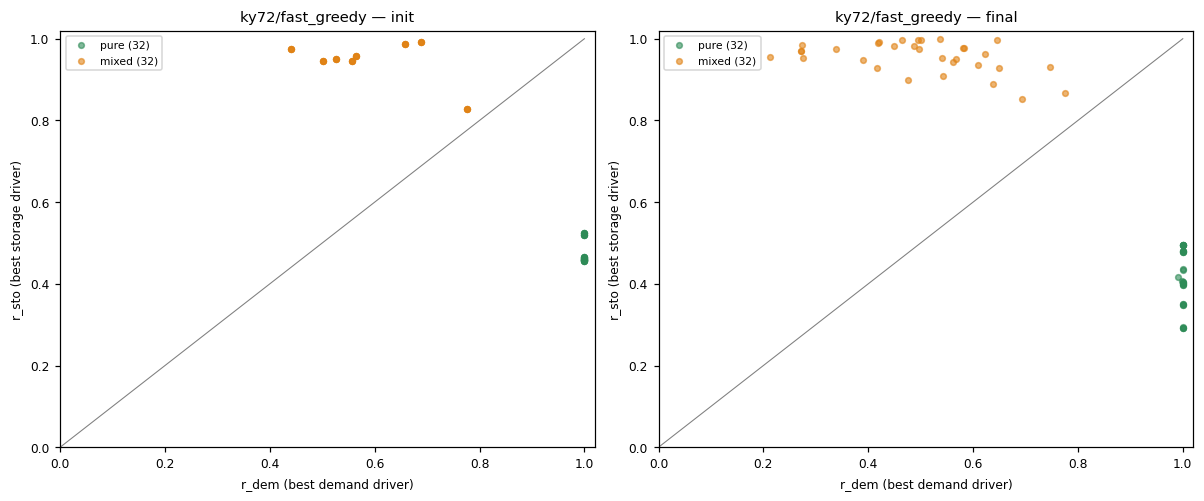

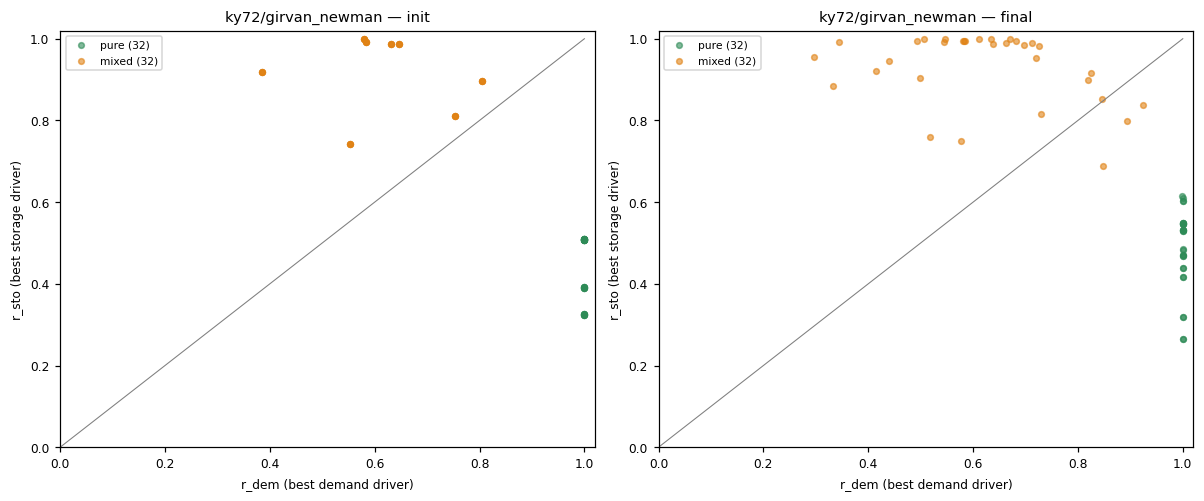

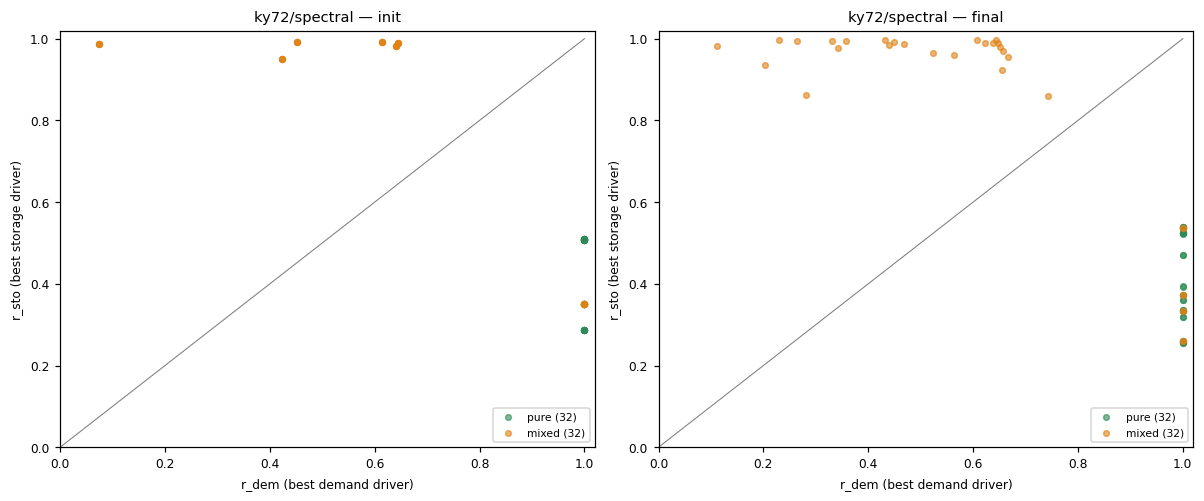

In [4]:
def drivers_for_world(w):
    P = target_probe(w)
    if P is None:
        return pd.DataFrame(), "no drift"
    (i0, i1), (f0, f1) = target_windows(P, w.params["sensor_placement"]["probe"]["settle"],
                                        w.params["patterns"])
    PL = w.catalog.load("sensor_placement")
    PL = PL[PL["kind"] == FLOW].reset_index(drop=True)
    els = PL["element"].astype(str).tolist()
    pumps, tanks = storage_map(w.network_model, P.flows.columns)
    S = storage_series(P, pumps, tanks)
    names = P.names
    dd = P.district_demand[names].to_numpy(float)
    dnames = names + ["total"]
    dem = np.column_stack([dd, dd.sum(axis=1)])
    snames = list(S.columns)
    rows = []
    for win, (lo, hi) in (("init", (i0, i1)), ("final", (f0, f1))):
        Q = fold(P.flows[els].to_numpy(float), P, lo, hi)
        Rd = corr_rows(Q, fold(dem, P, lo, hi))
        Rs = corr_rows(Q, fold(S.to_numpy(float), P, lo, hi)) if snames else np.full((len(els), 0), np.nan)
        R = np.abs(np.concatenate([Rd, Rs], axis=1))
        allnames = dnames + snames
        raw = P.flows[els].to_numpy(float)[lo:hi]
        for i, g in PL.iterrows():
            home = names.index(g["district"]) if g["district"] in names else None
            j = int(np.nanargmax(R[i])) if np.isfinite(R[i]).any() else None
            b = allnames[j] if j is not None else None
            rows.append({
                "network": w.row["network"], "districting": w.row["districting"],
                "sim_hash": w.sim_hash, "drift_district": P.drift["tgt_district"],
                "district": g["district"], "slot_class": g["slot_class"], "slot": g["slot"],
                "sensor": g["sensor"], "window": win,
                "r_own": abs(Rd[i, home]) if home is not None else np.nan,
                "r_dem": np.nanmax(np.abs(Rd[i])) if np.isfinite(Rd[i]).any() else np.nan,
                "r_sto": (np.nanmax(np.abs(Rs[i])) if Rs.shape[1] and np.isfinite(Rs[i]).any()
                          else np.nan),
                "best": b,
                "best_kind": (None if b is None else "total" if b == "total"
                              else b.split(":")[0] if ":" in b else "district"),
                "phi": opposite_share(raw[:, i])})
    return pd.DataFrame(rows), "ok"


frames, issues = [], []
for k, r in WORLDS.iterrows():
    w = ATLAS.world(r["sim_hash"])
    try:
        df, st = drivers_for_world(w)
        frames.append(df)
        if st != "ok":
            issues.append({"sim_hash": w.sim_hash, "issue": st})
    except Exception as exc:                              # reported, never swallowed silently
        issues.append({"sim_hash": w.sim_hash, "issue": f"{type(exc).__name__}: {exc}"[:200]})
    print(f"\r  check 2: {k + 1}/{len(WORLDS)} worlds", end="", flush=True)
print()
C2 = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
if issues:
    display(Markdown("**Worlds not analysed**")); display(pd.DataFrame(issues))

KEYS = ["network", "districting", "window", "slot_class"]
display(Markdown("**Which kind of series each placed gauge tracks best** (share of rows)"))
display(pd.crosstab([C2[k] for k in KEYS], C2["best_kind"], normalize="index").round(2)
        .join(C2.groupby(KEYS).size().rename("n")))
display(Markdown("**Medians**"))
display(C2.groupby(KEYS)[["r_own", "r_dem", "r_sto", "phi"]].median().round(3))
display(Markdown("**Same, by gauge** — a gauge placed in many worlds should behave consistently"))
display(C2.groupby(["network", "districting", "slot_class", "sensor", "window"])
        .agg(worlds=("sim_hash", "nunique"), r_own=("r_own", "median"), r_dem=("r_dem", "median"),
             r_sto=("r_sto", "median"), phi=("phi", "median"),
             best_kind=("best_kind", lambda s: s.mode().iat[0] if len(s.mode()) else None))
        .round(3))

groups = C2[["network", "districting"]].drop_duplicates().itertuples(index=False)
for net, meth in groups:
    G = C2[(C2["network"] == net) & (C2["districting"] == meth)]
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), squeeze=False)
    for ax, win in zip(axes[0], ("init", "final")):
        for cls, colour in (("pure", "#2e8b57"), ("mixed", "#e08214")):
            g = G[(G["window"] == win) & (G["slot_class"] == cls)]
            ax.scatter(g["r_dem"], g["r_sto"], s=14, alpha=0.6, c=colour, label=f"{cls} ({len(g)})")
        ax.plot([0, 1], [0, 1], color="0.5", lw=0.7)
        ax.set(xlim=(0, 1.02), ylim=(0, 1.02), xlabel="r_dem (best demand driver)",
               ylabel="r_sto (best storage driver)", title=f"{net}/{meth} — {win}")
        ax.legend(fontsize=7)
    fig.tight_layout(); plt.show()

## Check 3 — demand explainability (every label stack, every flow gauge)

Per label stack, the gauge's raw native weekly profile is stacked over $K+1$ segments: the shared
baseline window (taken once — every probe world has the same `init`) and the settled window of each
probe world. Each world moves one district, which decorrelates the demand regressors. Two nested
least-squares fits per gauge, with one intercept:

$$Q_s \approx c + \sum_k a_k D_k \quad(\text{demand}),\qquad Q_s \approx c + \sum_k a_k D_k + \sum_m b_m X_m \quad(\text{full})$$

with $X_m$ the pump flows and tank net inflows.

| column | measures | definition | range · expect if the hypothesis holds |
|---|---|---|---|
| `R2_dem` | how much of the gauge demand explains | adjusted $R^2$ of the demand fit: $1-(1-R^2)\frac{N-1}{N-p-1}$, $p=K$ | ≤ 1 · core ≈ 1; storage-driven links low |
| `R2_full` | same with storage regressors | adjusted $R^2$, $p=K+M$ | ≥ `R2_dem` up to noise |
| `dR2` | what storage state adds beyond demand | `R2_full − R2_dem` | ≈ 0 for demand-fed links · large = the link reads storage / control |

Adjusted $R^2$ so the extra $M$ regressors cannot buy `dR2` by themselves. Fitting is legitimate here:
this classifies what a link reads; it does not validate the mixture labels (that is the held-out
reconstruction). Placed gauges — from any world pointing at the stack — are marked. A stack whose
network has no pumps or tanks has `dR2 = NaN`.

  check 3: 3/3 label stacks


**By tier** — medians and the lower decile of `R2_dem`

n  R2_dem_med  R2_dem_q10  dR2_med  dR2_q90
network districting   stack        tier                                                     
ky72    fast_greedy   6998f19293fd core        229       0.998       0.946    0.000    0.024
                                   foreign      91       0.101       0.024    0.899    0.972
                                   transition  284       0.085       0.013    0.906    0.983
        girvan_newman 1257509ecd5b core        253       0.998       0.862    0.000    0.111
                                   foreign      61       0.166       0.080    0.823    0.905
                                   transition  290       0.195       0.062    0.803    0.924
        spectral      42e9febc3a53 core        241       0.998       0.928    0.000    0.056
                                   foreign      56       0.116       0.014    0.880    0.984
                                   transition  307       0.124       0.029    0.869    0.969

**Placed gauges**

,network,districting,stack,id,home,placed,tier,purity,R2_dem,R2_full,dR2
0,ky72,fast_greedy,6998f19293fd,q_P-191,District_A,mixed,transition,0.239,0.582,0.951,0.369
1,ky72,fast_greedy,6998f19293fd,q_P-288,District_A,mixed,transition,0.438,0.236,0.998,0.762
2,ky72,fast_greedy,6998f19293fd,q_P-164,District_B,mixed,transition,0.364,0.204,0.993,0.790
3,ky72,fast_greedy,6998f19293fd,q_P-617,District_B,mixed,transition,0.163,0.284,0.980,0.696
4,ky72,fast_greedy,6998f19293fd,q_P-10,District_C,mixed,transition,0.351,0.346,0.998,0.652
5,ky72,fast_greedy,6998f19293fd,q_P-267,District_C,mixed,transition,0.609,0.133,0.998,0.864
6,ky72,fast_greedy,6998f19293fd,q_P-246,District_D,mixed,transition,0.470,0.150,1.000,0.849
7,ky72,fast_greedy,6998f19293fd,q_P-537,District_D,mixed,transition,0.629,0.368,0.983,0.616
8,ky72,fast_greedy,6998f19293fd,q_P-467,District_A,pure,core,1.000,0.996,0.996,0.000
9,ky72,fast_greedy,6998f19293fd,q_P-499,District_A,pure,core,1.000,1.000,1.000,0.000


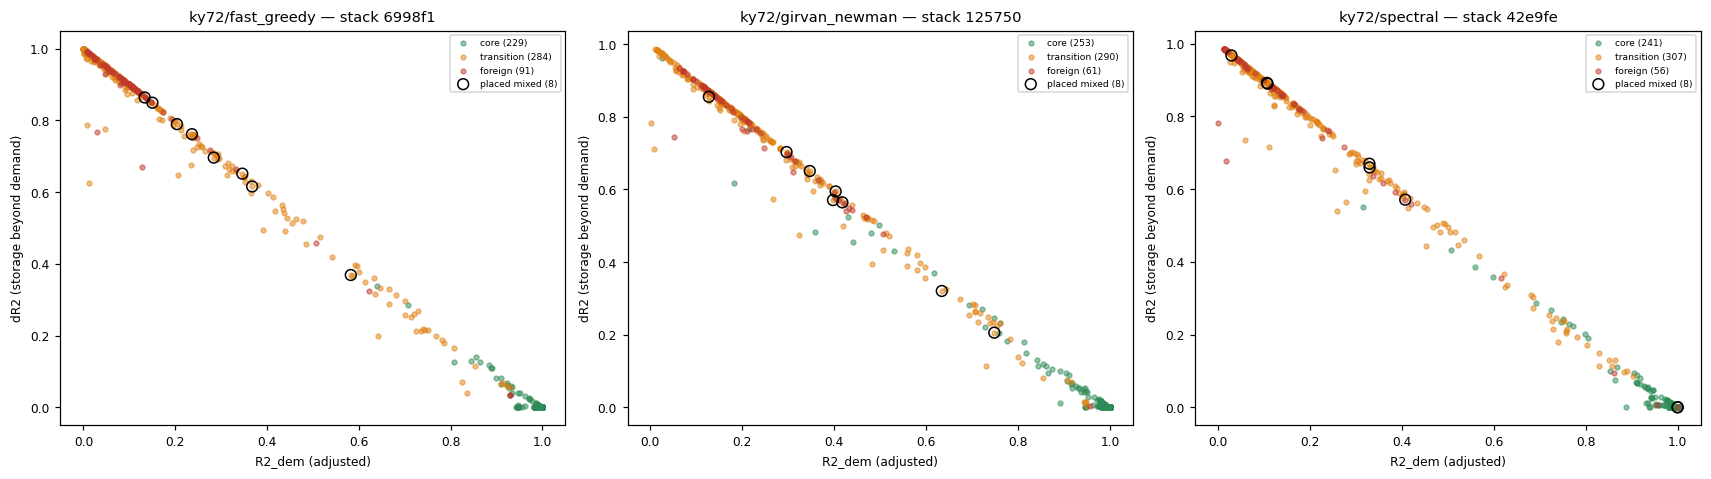

In [5]:
def stack_paths(worlds):
    # distinct label stacks of the study, with the worlds that use each
    out = {}
    for _, r in worlds.iterrows():
        p = r.get("selection_path") if bool(r.get("same_stack")) else r.get("label_path")
        if p:
            out.setdefault(p, []).append(r["sim_hash"])
    return out


def adj_r2(Y, X):
    # adjusted R^2 per column of Y for the least-squares fit on X (X carries the intercept)
    B, *_ = np.linalg.lstsq(X, Y, rcond=None)
    res = ((Y - X @ B) ** 2).sum(axis=0)
    tot = ((Y - Y.mean(axis=0)) ** 2).sum(axis=0)
    n, p = X.shape[0], X.shape[1] - 1
    r2 = np.where(tot > 1e-12, 1.0 - res / np.where(tot > 1e-12, tot, 1.0), np.nan)
    return 1.0 - (1.0 - r2) * (n - 1) / max(n - p - 1, 1)


def explain_stack(path, sims):
    L = store.load_stack(path, with_probes=True)          # not cached: probe series are large
    if not L.probes:
        return pd.DataFrame(), "no retained probe worlds"
    settle = L.spec["probe"]["settle"]
    M = L.mixture[L.mixture["kind"] == FLOW].reset_index(drop=True)
    w0 = ATLAS.world(sims[0])
    wn = w0.network_model
    ks = sorted(L.probes)
    P0 = L.probes[ks[0]]
    M = M[M["element"].astype(str).isin(P0.flows.columns)].reset_index(drop=True)
    els = M["element"].astype(str).tolist()
    pumps, tanks = storage_map(wn, P0.flows.columns)
    names = P0.names
    segs = [(P0, stack_windows(P0, settle)[0])] + [(L.probes[k], stack_windows(L.probes[k], settle)[1])
                                                   for k in ks]
    Q, D, S = [], [], []
    for P, (lo, hi) in segs:
        Q.append(fold(P.flows[els].to_numpy(float), P, lo, hi))
        D.append(fold(P.district_demand[names].to_numpy(float), P, lo, hi))
        S.append(fold(storage_series(P, pumps, tanks).to_numpy(float), P, lo, hi))
    Y = np.concatenate(Q, axis=1).T                         # N x gauges
    Xd = np.column_stack([np.ones(Y.shape[0]), np.concatenate(D, axis=1).T])
    r2d = adj_r2(Y, Xd)
    if S[0].shape[0]:
        Xf = np.column_stack([Xd, np.concatenate(S, axis=1).T])
        r2f = adj_r2(Y, Xf)
    else:
        r2f = np.full_like(r2d, np.nan)
    placed = {}
    for h in sims:
        PL = ATLAS.world(h).catalog.load("sensor_placement")
        for _, g in PL[PL["kind"] == FLOW].iterrows():
            placed.setdefault(g["sensor"], set()).add(g["slot_class"])
    out = M[["id", "home", "tier", "purity", "w_second"]].copy()
    out["R2_dem"], out["R2_full"] = r2d, r2f
    out["dR2"] = r2f - r2d
    out["placed"] = out["id"].map(lambda i: "/".join(sorted(placed.get(i, []))) or "")
    out.insert(0, "stack", L.stack_hash)
    out.insert(0, "districting", L.method)
    out.insert(0, "network", L.network)
    out["n_samples"], out["n_storage"] = Y.shape[0], S[0].shape[0]
    return out, "ok"


frames, issues = [], []
paths = stack_paths(WORLDS)
for k, (path, sims) in enumerate(paths.items()):
    try:
        df, st = explain_stack(path, sims)
        frames.append(df)
        if st != "ok":
            issues.append({"stack": path, "issue": st})
    except Exception as exc:
        issues.append({"stack": path, "issue": f"{type(exc).__name__}: {exc}"[:200]})
    print(f"\r  check 3: {k + 1}/{len(paths)} label stacks", end="", flush=True)
print()
C3 = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
if issues:
    display(Markdown("**Stacks not analysed**")); display(pd.DataFrame(issues))

display(Markdown("**By tier** — medians and the lower decile of `R2_dem`"))
display(C3.groupby(["network", "districting", "stack", "tier"])
        .agg(n=("id", "size"), R2_dem_med=("R2_dem", "median"),
             R2_dem_q10=("R2_dem", lambda s: s.quantile(0.10)),
             dR2_med=("dR2", "median"), dR2_q90=("dR2", lambda s: s.quantile(0.90)))
        .round(3))
display(Markdown("**Placed gauges**"))
display(C3[C3["placed"] != ""].sort_values(["network", "districting", "stack", "placed", "home"])
        [["network", "districting", "stack", "id", "home", "placed", "tier", "purity",
          "R2_dem", "R2_full", "dR2"]].round(3).reset_index(drop=True))

TIER_COLOUR = {"core": "#2e8b57", "transition": "#e08214", "foreign": "#c0392b",
               "unusable": "#c8ccd0"}
keys = C3[["network", "districting", "stack"]].drop_duplicates().itertuples(index=False)
keys = list(keys)
ncol = 3
fig, axes = plt.subplots(int(np.ceil(len(keys) / ncol)), ncol,
                         figsize=(5.2 * ncol, 4.4 * int(np.ceil(len(keys) / ncol))), squeeze=False)
for ax, (net, meth, h) in zip(axes.ravel(), keys):
    G = C3[(C3["network"] == net) & (C3["districting"] == meth) & (C3["stack"] == h)]
    for tier, colour in TIER_COLOUR.items():
        g = G[G["tier"] == tier]
        if len(g):
            ax.scatter(g["R2_dem"], g["dR2"], s=10, alpha=0.5, c=colour, label=f"{tier} ({len(g)})")
    pm = G[G["placed"].str.contains("mixed")]
    ax.scatter(pm["R2_dem"], pm["dR2"], s=50, facecolors="none", edgecolors="k", lw=1,
               label=f"placed mixed ({len(pm)})")
    ax.set(xlabel="R2_dem (adjusted)", ylabel="dR2 (storage beyond demand)",
           title=f"{net}/{meth} — stack {h[:6]}")
    ax.legend(fontsize=6)
for ax in axes.ravel()[len(keys):]:
    ax.axis("off")
fig.tight_layout(); plt.show()

# Block A — the generating mechanism

Checks 1–3 showed that non-core flow gauges read storage state. Block A asks **what that storage state
is and how it moves**, before any tiering or labelling is built on it. One pass over **every world**:
the 12 target worlds and every probe world of the study's label stacks, each on its two windows
(target: `init` / settled `final`, `verify_placement`'s rule; probe: baseline / settled,
`build_mixture`'s rule). Flows raw, `.inp` orientation, as before.

| test | question |
|---|---|
| A1 storage inventory | which tanks and pumps are actually active, and why the others are not |
| A2 control response | which drifts move the pump schedule, and by how much |
| A3 event alignment | are a gauge's abrupt changes pump events (non-linear test, independent of R²) |
| A4 lag structure | where is there temporal precedence between demand and a gauge |

The pass is one cell (stacks are loaded one at a time with their probe worlds, then released); the
four read-outs below it only display.

In [6]:
LAG_H = 48            # A4: lags searched, +- hours
BIG_Q = 0.95          # A3: a "large step" is above this quantile of the gauge's own |dQ| in the window
NEAR = 1              # A3: steps either side of a pump switch that count as "at" the switch
LEVEL_TOL = 0.01      # A1: m; level within this of a bound counts as "at the bound"


def pump_on(q):
    q = np.asarray(q, float)
    return np.abs(q) > 1e-6 * max(np.abs(q).max(), 1e-12)


def circ_mean_h(hours_of_day):
    # circular mean time of day, hours; NaN if empty
    h = np.asarray(hours_of_day, float)
    if not len(h):
        return np.nan
    a = 2 * np.pi * h / 24.0
    return float((np.degrees(np.arctan2(np.sin(a).mean(), np.cos(a).mean())) / 15.0) % 24.0)


def circ_diff_h(b, a):
    return np.nan if np.isnan(a) or np.isnan(b) else float(((b - a + 12.0) % 24.0) - 12.0)


def anomalies(X, P, lo, hi):
    # (n_steps, m) window -> minus its own weekly profile (tiled) and a linear trend, per column
    Xw = np.asarray(X, float)[lo:hi]
    sd = P.steps_day
    prof = np.atleast_2d(sp.weekly_profile(Xw if Xw.ndim > 1 else Xw[:, None], sd, step0=lo))
    a = np.arange(lo, hi)
    E = Xw - prof[:, ((a // sd) % 7) * sd + a % sd].T
    t = np.column_stack([np.ones(len(a)), (a - a.mean()) / max(len(a), 1)])
    B, *_ = np.linalg.lstsq(t, E, rcond=None)
    return E - t @ B, Xw


def xcorr(A, b, L):
    # Pearson r(tau) of A[:, j](t) with b(t - tau), tau = -L..L (tau > 0: A lags b). A (n, g), b (n,)
    n = A.shape[0]
    Az = (A - A.mean(0)) / np.where(A.std(0) > 1e-12, A.std(0), np.nan)
    bz = (b - b.mean()) / (b.std() if b.std() > 1e-12 else np.nan)
    nfft = 1 << int(np.ceil(np.log2(2 * n)))
    FA = np.fft.rfft(Az.astype(np.float32), nfft, axis=0)
    Fb = np.fft.rfft(bz.astype(np.float32), nfft)
    cc = np.fft.irfft(FA * np.conj(Fb)[:, None], nfft, axis=0) / n
    return np.concatenate([cc[nfft - L:], cc[:L + 1]], axis=0)        # (2L+1, g)


def analyse_record(P, wins, wn, M, meta, out):
    pumps, tanks = storage_map(wn, P.flows.columns)
    hours, sd = float(P.time["resolution_h"]), P.steps_day
    L = int(round(LAG_H / hours))
    lags_h = np.arange(-L, L + 1) * hours
    names = P.names
    els = M["element"].astype(str).tolist()
    S = storage_series(P, pumps, tanks)
    dd = P.district_demand[names].to_numpy(float)
    tot = dd.sum(axis=1)
    pump_rows = []
    for win, (lo, hi) in zip(("init", "final"), wins):
        n = hi - lo
        # ---- A1 tanks -------------------------------------------------------------
        for tk, inc in tanks.items():
            node = wn.get_node(tk)
            lev = (P.pressures[tk].to_numpy(float)[lo:hi] if tk in P.pressures.columns
                   else np.full(n, np.nan))
            q_in = S[f"tank:{tk}"].to_numpy(float)[lo:hi]
            days = n // sd
            amp = (np.nanmean(np.ptp(lev[:days * sd].reshape(days, sd), axis=1))
                   if days and np.isfinite(lev).any() else np.nan)
            out["tank"].append({**meta, "window": win, "tank": tk,
                                "level_mean": np.nanmean(lev), "level_sd": np.nanstd(lev),
                                "daily_amp": amp,
                                "at_min": float(np.nanmean(lev <= node.min_level + LEVEL_TOL)),
                                "at_max": float(np.nanmean(lev >= node.max_level - LEVEL_TOL)),
                                "min_level": node.min_level, "max_level": node.max_level,
                                "inflow_sd": float(q_in.std())})
            for ln, _ in inc:
                out["incident"].append({**meta, "window": win, "tank": tk, "link": ln,
                                        "flow_sd": float(P.flows[ln].to_numpy(float)[lo:hi].std())})
        # ---- A1/A2 pumps ----------------------------------------------------------
        sw_by = {}                                       # pump -> switch mask (n-1,)
        for p in pumps:
            q = P.flows[p].to_numpy(float)
            on = pump_on(q)[lo:hi]
            d = np.diff(on.astype(int))
            sw_by[p] = d != 0
            up, dn = np.where(d == 1)[0] + 1, np.where(d == -1)[0] + 1
            se = np.flatnonzero(np.diff(np.r_[0, on.astype(int), 0]) != 0).reshape(-1, 2)
            runs = se[:, 1] - se[:, 0]                      # on-run lengths, steps
            pump_rows.append({"window": win, "pump": p, "duty": float(on.mean()),
                              "switches_per_day": float((d != 0).sum() / (n / sd)),
                              "on_tod": circ_mean_h(((up + lo) % sd) * hours),
                              "off_tod": circ_mean_h(((dn + lo) % sd) * hours),
                              "mean_on_h": float(runs.mean() * hours) if len(runs) else np.nan,
                              "on_flow": float(q[lo:hi][on].mean()) if on.any() else 0.0})
        # ---- A3 event alignment, per pump -----------------------------------------
        # Pooling every pump's switches into one "any switch" mask saturates on a
        # multi-pump network (D-Town: 89.5% of steps sit next to some switch), so each
        # pump is tested on its own and a gauge keeps the pump it aligns with best.
        Q = P.flows[els].to_numpy(float)[lo:hi]
        dQ = np.abs(np.diff(Q, axis=0))
        thr = np.quantile(dQ, BIG_Q, axis=0)
        big = (dQ > thr) & (dQ > 1e-9)
        nb_ = big.sum(axis=0)
        ng = Q.shape[1]
        lift_b, E_b, ch_b = np.full(ng, np.nan), np.full(ng, np.nan), np.full(ng, np.nan)
        pump_b = np.full(ng, None, dtype=object)
        for p, swp in sw_by.items():
            if not swp.any():
                continue
            near = swp.copy()
            for k_ in range(1, NEAR + 1):
                near[k_:] |= swp[:-k_]
                near[:-k_] |= swp[k_:]
            ch = float(near.mean())
            E_p = np.where(nb_ > 0, (big & near[:, None]).sum(axis=0) / np.maximum(nb_, 1), np.nan)
            L_p = E_p / ch
            upd = np.isfinite(L_p) & (np.isnan(lift_b) | (L_p > lift_b))
            lift_b[upd], E_b[upd], ch_b[upd] = L_p[upd], E_p[upd], ch
            pump_b[upd] = p
        # ---- A4 lags on anomalies ---------------------------------------------------
        EQ, _ = anomalies(P.flows[els].to_numpy(float), P, lo, hi)
        ED, D0 = anomalies(np.column_stack([dd, tot]), P, lo, hi)
        anom_q = EQ.std(0) / np.where(Q.std(0) > 1e-12, Q.std(0), np.nan)
        res = {}
        for j, nm in enumerate(names + ["total"]):
            R = xcorr(EQ, ED[:, j], L)
            res[nm] = (R, float(ED[:, j].std() / max(D0[:, j].std(), 1e-12)))
        act = [c for c in S.columns if c.startswith("tank:")]
        if act:
            k = int(np.argmax([S[c].to_numpy(float)[lo:hi].std() for c in act]))
            ES, _ = anomalies(S[[act[k]]].to_numpy(float), P, lo, hi)
            res["tank_inflow"] = (xcorr(EQ, ES[:, 0], L), np.nan)
        for i, g in M.reset_index(drop=True).iterrows():
            row = {**meta, "window": win, "id": g["id"], "home": g["home"], "tier": g["tier"],
                   "placed": g["placed"], "E": E_b[i], "chance": ch_b[i],
                   "lift": lift_b[i], "lift_pump": pump_b[i], "anom_ratio": anom_q[i]}
            out["event"].append({k_: row[k_] for k_ in (*meta, "window", "id", "home", "tier",
                                                        "placed", "E", "chance", "lift",
                                                        "lift_pump")})
            lrow = {**meta, "window": win, "id": g["id"], "home": g["home"], "tier": g["tier"],
                    "placed": g["placed"], "anom_ratio": anom_q[i]}
            for key, drv in (("home", g["home"]), ("total", "total"), ("tank", "tank_inflow")):
                if drv not in res:
                    continue
                r = res[drv][0][:, i]
                if not np.isfinite(r).any():
                    continue
                j = int(np.nanargmax(np.abs(r)))
                lrow[f"tau_{key}_h"] = float(lags_h[j])
                lrow[f"r_{key}_peak"] = float(r[j])
                lrow[f"r_{key}_0"] = float(r[L])
            lrow["drv_anom_home"] = res[g["home"]][1] if g["home"] in res else np.nan
            out["lag"].append(lrow)
    # ---- A2 per world: init vs final ------------------------------------------------
    PR = pd.DataFrame(pump_rows)
    for p in pumps:
        a = PR[(PR["pump"] == p) & (PR["window"] == "init")].iloc[0]
        b = PR[(PR["pump"] == p) & (PR["window"] == "final")].iloc[0]
        (i0, i1), (f0, f1) = wins
        drift = meta["drift"]
        k = names.index(drift) if drift in names else None
        lvl = lambda x: float(x[f0:f1].mean() / max(x[i0:i1].mean(), 1e-12) - 1.0)
        out["pump"].append({**meta, "pump": p,
                            "duty_init": a["duty"], "duty_final": b["duty"],
                            "d_duty": b["duty"] - a["duty"],
                            "sw_day_init": a["switches_per_day"], "sw_day_final": b["switches_per_day"],
                            "on_tod_init": a["on_tod"], "d_on_tod_h": circ_diff_h(b["on_tod"], a["on_tod"]),
                            "off_tod_init": a["off_tod"], "d_off_tod_h": circ_diff_h(b["off_tod"], a["off_tod"]),
                            "mean_on_h_init": a["mean_on_h"], "mean_on_h_final": b["mean_on_h"],
                            "on_flow_init": a["on_flow"], "on_flow_final": b["on_flow"],
                            "dD_drift": lvl(dd[:, k]) if k is not None else np.nan,
                            "dD_total": lvl(tot)})


A = {k: [] for k in ("tank", "incident", "pump", "event", "lag")}
issues = []
paths = stack_paths(WORLDS)
for si, (path, sims) in enumerate(paths.items()):
    L_ = store.load_stack(path, with_probes=True)
    settle = L_.spec["probe"]["settle"]
    w0 = ATLAS.world(sims[0])
    wn = w0.network_model
    placed = {}
    for h in sims:
        PL = ATLAS.world(h).catalog.load("sensor_placement")
        for _, g in PL[PL["kind"] == FLOW].iterrows():
            placed.setdefault(g["sensor"], set()).add(g["slot_class"])
    M = L_.mixture[L_.mixture["kind"] == FLOW][["id", "element", "home", "tier"]].copy()
    M["placed"] = M["id"].map(lambda i: "/".join(sorted(placed.get(i, []))))
    M = M[~M["element"].astype(str).isin(set(wn.pump_name_list))]   # pumps are not meters
    base = {"network": L_.network, "districting": L_.method, "stack": L_.stack_hash[:6]}
    jobs = [("probe", k, None) for k in sorted(L_.probes)] + [("target", None, h) for h in sims]
    for source, k, h in jobs:
        try:
            if source == "probe":
                P = L_.probes[k]
                wins = stack_windows(P, settle)
                meta = {**base, "source": "probe", "world": f"probe:{k}", "drift": k}
            else:
                w = ATLAS.world(h)
                P = target_probe(w, with_pressures=True)
                wins = target_windows(P, w.params["sensor_placement"]["probe"]["settle"],
                                      w.params["patterns"])
                meta = {**base, "source": "target", "world": h[:8], "drift": P.drift["tgt_district"]}
            Mi = M[M["element"].astype(str).isin(P.flows.columns)]
            analyse_record(P, wins, wn, Mi, meta, A)
        except Exception as exc:                          # reported, never swallowed silently
            issues.append({**base, "source": source, "world": k or h,
                           "issue": f"{type(exc).__name__}: {exc}"[:200]})
        print(f"\r  block A: stack {si + 1}/{len(paths)} — {source} {k or h[:8]}      ",
              end="", flush=True)
    del L_
print()
A = {k: pd.DataFrame(v) for k, v in A.items()}
if issues:
    display(Markdown("**Records not analysed**")); display(pd.DataFrame(issues))
print({k: len(v) for k, v in A.items()})

  block A: stack 3/3 — target d767277b       
{'tank': 144, 'incident': 192, 'pump': 24, 'event': 28944, 'lag': 28944}


### A1 — storage inventory

Per tank and window: level from the tank's pressure (= level in wntr), its sd, the mean daily range
(`daily_amp`), the share of time within `LEVEL_TOL` of `min_level` / `max_level`, and the sd of its net
inflow. A tank is **inert** if its level sd and its net-inflow sd are both ~0 in every world: it never
exchanges water, and it cannot carry any coupling. Its incident links' `.inp` status and check-valve flag
say why. The `.inp` controls are printed once per network.

| column | definition | reading |
|---|---|---|
| `level_sd`, `daily_amp` | sd of level; mean over days of (max − min) level | ~0 = static tank |
| `at_min`, `at_max` | share of steps with level within `LEVEL_TOL` of the bound | ≈ 1 at `max` = pinned full (no inflow possible); ≈ 1 at `min` = drained |
| `inflow_sd` | sd of the signed sum of incident link flows | ~0 = no exchange |
| pump `duty`, `switches_per_day`, `mean_on_h` | share of time on; status changes per day; mean on-run length | the control cycle |

In [7]:
for net in A["tank"]["network"].unique():
    wn = ATLAS.network_model(net)
    ctr = list(wn.controls())
    print(f"{net}: {len(ctr)} controls")
    for name, c in ctr:
        print(f"  {name}: {c}")
    rows = []
    for t in wn.tank_name_list:
        for ln in wn.get_links_for_node(t):
            l = wn.get_link(ln)
            rows.append({"tank": t, "link": ln, "type": l.link_type,
                         "from": l.start_node_name, "to": l.end_node_name,
                         "initial_status": str(l.initial_status),
                         "check_valve": getattr(l, "check_valve", None)})
    I = pd.DataFrame(rows)
    fs = (A["incident"][A["incident"]["network"] == net].groupby("link")["flow_sd"]
          .agg(flow_sd_med="median", flow_sd_max="max"))
    display(Markdown(f"**{net} — tank incident links** (flow sd across every world and window)"))
    display(I.merge(fs, left_on="link", right_index=True, how="left").round(4))

display(Markdown("**Tanks — across every world and window**"))
display(A["tank"].groupby(["network", "tank"])
        .agg(records=("world", "size"), level_mean=("level_mean", "median"),
             level_sd_med=("level_sd", "median"), level_sd_max=("level_sd", "max"),
             daily_amp=("daily_amp", "median"), at_min=("at_min", "median"),
             at_max=("at_max", "median"), inflow_sd_max=("inflow_sd", "max"),
             min_level=("min_level", "first"), max_level=("max_level", "first"))
        .round(4))
display(Markdown("**Pumps — init window, across every world**"))
display(A["pump"].groupby(["network", "pump"])
        [["duty_init", "sw_day_init", "mean_on_h_init", "on_tod_init", "off_tod_init", "on_flow_init"]]
        .describe().T.round(3))

ky72: 2 controls
  control 1: IF TANK T-3 LEVEL BELOW 29.6101008 THEN PUMP ~@Pump-1 STATUS IS OPEN PRIORITY 3
  control 2: IF TANK T-3 LEVEL ABOVE 35.0965008 THEN PUMP ~@Pump-1 STATUS IS CLOSED PRIORITY 3


**ky72 — tank incident links** (flow sd across every world and window)

,tank,link,type,from,to,initial_status,check_valve,flow_sd_med,flow_sd_max
0,T-1,P-6,Pipe,T-1,J-9,Open,False,1.0229,2.0600
1,T-2,P-107,Pipe,J-40,T-2,Open,False,0.7316,1.3276
2,T-2,P-157,Pipe,J-67,T-2,Open,False,0.8618,1.6248
3,T-3,P-213,Pipe,T-3,J-8,Open,False,35.3773,37.1866


**Tanks — across every world and window**

records  level_mean  level_sd_med  level_sd_max  daily_amp  at_min  at_max  inflow_sd_max  min_level  max_level
network tank                                                                                                                 
ky72    T-1        48     48.1534        0.1081        0.2179     0.0151  0.0000  0.9983         2.0600    35.9664    48.1584
        T-2        48     38.6725        0.0195        0.0520     0.0019  0.0000  0.9983         2.4853    33.4919    38.6735
        T-3        48     32.0429        1.7373        2.0014     5.2894  0.0025  0.0000        37.1866    28.0863    35.7063

**Pumps — init window, across every world**

network                  ky72
pump                 ~@Pump-1
duty_init      count   24.000
               mean     0.553
               std      0.003
               min      0.549
               25%      0.549
               50%      0.555
               75%      0.556
               max      0.556
sw_day_init    count   24.000
               mean     1.984
               std      0.000
               min      1.984
               25%      1.984
               50%      1.984
               75%      1.984
               max      1.984
mean_on_h_init count   24.000
               mean    13.329
               std      0.077
               min     13.219
               25%     13.227
               50%     13.375
               75%     13.390
               max     13.390
on_tod_init    count   24.000
               mean    14.229
               std      0.178
               min     14.012
               25%     14.017
               50%     14.230
               75%     14.437
               max     14.446
off_tod_init   count   24.000
               mean     3.588
               std      0.284
               min      3.269
               25%      3.273
               50%      3.545
               75%      3.938
               max      3.957
on_flow_init   count   24.000
               mean    59.742
               std      0.095
               min     59.613
               25%     59.613
               50%     59.782
               75%     59.829
               max     59.830

### A2 — control response per drift

Per world, init → final: change of pump duty, of the mean switch-on / switch-off time of day (circular,
hours), of the on-run length, against the drift's level change on its own district
$\Delta\bar D_k = \bar D_k^{\text{final}}/\bar D_k^{\text{init}}-1$ and on the network total
$\Delta\bar D_{\text{tot}}$. The fast_greedy plots suggested A and B propagate and C and D do not; this
asks it of every world, and whether the split follows the sign or the size of $\Delta\bar D_{\text{tot}}$.

| column | definition | reading |
|---|---|---|
| `d_duty` | duty(final) − duty(init) | ≈ 0 = the drift did not reach the storage channel |
| `d_on_tod_h`, `d_off_tod_h` | shift of the mean switch-on / -off time of day | where in the day the coupling acts |
| `dD_drift`, `dD_total` | relative level change of the drifting district / of total demand | the excitation as the storage sees it |

Probe worlds and target worlds are both shown: for the same partition and drift district they should
agree, and where they do not, the seed or horizon is doing the work.

,network,districting,source,world,drift,pump,dD_drift,dD_total,duty_init,d_duty,d_on_tod_h,d_off_tod_h,mean_on_h_init,mean_on_h_final
0,ky72,fast_greedy,probe,probe:District_A,District_A,~@Pump-1,1.215,0.256,0.556,0.133,-1.331,-1.043,13.390,22.974
1,ky72,fast_greedy,target,0b4750d3,District_A,~@Pump-1,1.212,0.255,0.555,0.134,-1.361,-1.025,13.363,23.050
2,ky72,fast_greedy,probe,probe:District_B,District_B,~@Pump-1,1.202,0.251,0.556,0.130,-1.292,-1.073,13.390,22.965
3,ky72,fast_greedy,target,13f0f426,District_B,~@Pump-1,1.197,0.251,0.555,0.132,-1.306,-1.051,13.363,23.015
4,ky72,fast_greedy,probe,probe:District_C,District_C,~@Pump-1,-0.394,-0.126,0.556,-0.073,1.527,-0.390,13.390,11.571
5,ky72,fast_greedy,target,312ef90c,District_C,~@Pump-1,-0.393,-0.125,0.555,-0.072,1.519,-0.370,13.363,11.571
6,ky72,fast_greedy,probe,probe:District_D,District_D,~@Pump-1,-0.543,-0.141,0.556,-0.059,0.410,-0.815,13.390,11.910
7,ky72,fast_greedy,target,8a9b36d7,District_D,~@Pump-1,-0.547,-0.143,0.555,-0.060,0.442,-0.826,13.363,11.845
8,ky72,girvan_newman,probe,probe:District_A,District_A,~@Pump-1,1.204,0.528,0.549,0.294,-4.795,-1.846,13.227,45.699
9,ky72,girvan_newman,target,35d8d9bc,District_A,~@Pump-1,1.216,0.533,0.549,0.298,-5.079,-2.449,13.219,47.062


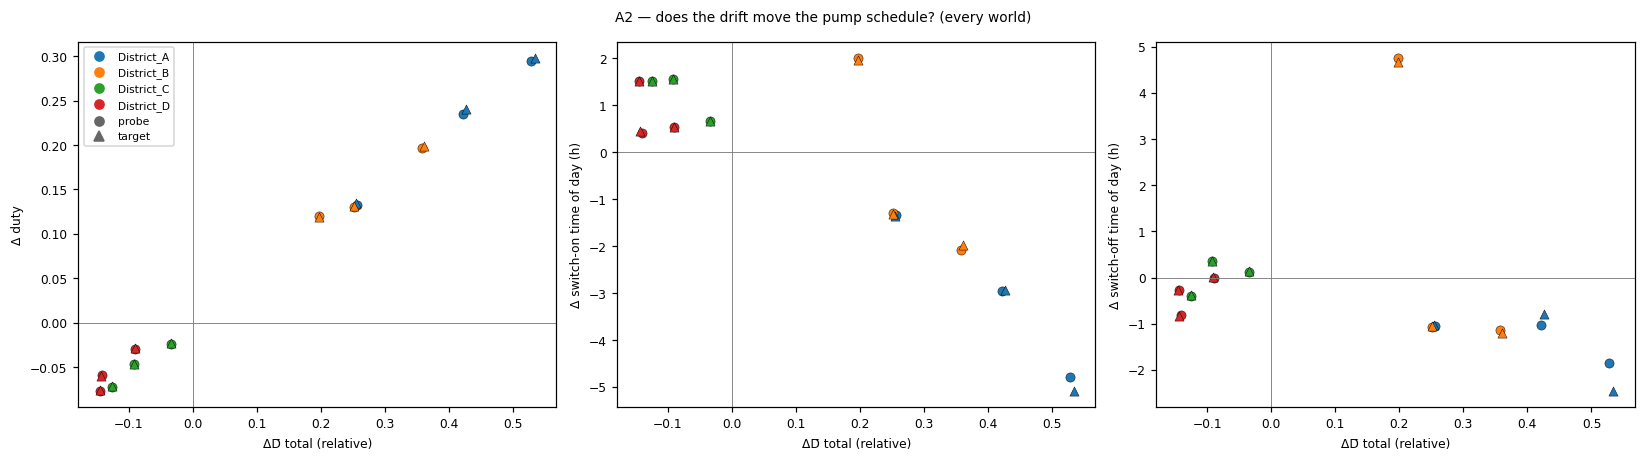

In [8]:
cols = ["network", "districting", "source", "world", "drift", "pump", "dD_drift", "dD_total",
        "duty_init", "d_duty", "d_on_tod_h", "d_off_tod_h", "mean_on_h_init", "mean_on_h_final"]
display(A["pump"][cols].sort_values(["districting", "drift", "source"]).round(3)
        .reset_index(drop=True))

DCOL = dict(zip(sorted(A["pump"]["drift"].unique()), plt.cm.tab10.colors))
MK = {"probe": "o", "target": "^"}
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for _, r in A["pump"].iterrows():
    for ax, y in zip(axes, ("d_duty", "d_on_tod_h", "d_off_tod_h")):
        ax.scatter(r["dD_total"], r[y], c=[DCOL[r["drift"]]], marker=MK[r["source"]], s=36,
                   edgecolors="k", lw=0.3)
for ax, y in zip(axes, ("Δ duty", "Δ switch-on time of day (h)", "Δ switch-off time of day (h)")):
    ax.axhline(0, color="0.5", lw=0.6); ax.axvline(0, color="0.5", lw=0.6)
    ax.set(xlabel="ΔD̄ total (relative)", ylabel=y)
from matplotlib.lines import Line2D
axes[0].legend(handles=[Line2D([], [], ls="", marker="o", color=c, label=d) for d, c in DCOL.items()]
               + [Line2D([], [], ls="", marker=m, color="0.4", label=s) for s, m in MK.items()],
               fontsize=7)
fig.suptitle("A2 — does the drift move the pump schedule? (every world)", fontsize=9)
fig.tight_layout(); plt.show()

### A3 — event alignment (every flow gauge, every world, both windows)

Per gauge and window: of its **large steps** ($\lvert\Delta Q_t\rvert$ above its own `BIG_Q` quantile),
the share that fall within `NEAR` steps of a status change of **one pump**, against the share of **all**
steps that do (that pump's chance rate). Each pump is tested separately and the gauge keeps the pump it
aligns with best (`lift_pump`): pooling all pumps into one "any switch" mask saturates on a multi-pump
network (D-Town: 89.5% of steps sit next to some switch, so every gauge hit the 1.12 ceiling).
Pump links themselves are excluded from the gauge population — they are no longer placement candidates.

| column | definition | reading |
|---|---|---|
| `E` | $\#\{\text{large steps near a switch}\}/\#\{\text{large steps}\}$ | [0, 1] |
| `chance` | $\#\{\text{steps near a switch}\}/\#\{\text{steps}\}$ | the rate `E` takes if steps ignore the pump |
| `lift`, `lift_pump` | max over pumps of `E / chance`; the pump attaining it | ≈ 1 = abrupt changes unrelated to the pump (demand-fed) · ≫ 1 = abrupt changes ARE pump events |

Non-linear and threshold-free in the sense that matters: it does not assume flow is a linear function of
anything, so it tests the switching claim independently of checks 2–3. Per gauge, the median over every
world and window is what is tabulated.

**By tier** — median lift, and share of gauges with lift > 2

n  lift_med  lift_q10  lift_q90  share_gt2  chance
network districting   tier                                                            
ky72    fast_greedy   core        229     0.918     0.000     1.139      0.083   0.248
                      foreign      91     4.031     4.018     4.031      0.978   0.248
                      transition  283     4.031     4.005     4.031      0.982   0.248
        girvan_newman core        253     0.319     0.000     3.321      0.146   0.248
                      foreign      61     4.031     4.005     4.031      0.967   0.248
                      transition  289     4.031     4.005     4.031      0.965   0.248
        spectral      core        241     0.542     0.027     1.470      0.087   0.248
                      foreign      55     4.031     1.690     4.031      0.891   0.248
                      transition  307     4.031     4.005     4.031      0.984   0.248

**Which pump drives which gauges** — gauges with lift > 2, by home district (`pump_agree` = share of records naming the same pump)

lift_pump                 ~@Pump-1
districting   home                
fast_greedy   District_A       188
              District_B       118
              District_C        22
              District_D        58
girvan_newman District_A       222
              District_B        51
              District_C        86
              District_D        16
spectral      District_A       153
              District_B       201
              District_C        18

**Placed gauges**

,network,districting,id,home,tier,placed,lift,E,chance,lift_pump,pump_agree,records
0,ky72,fast_greedy,q_P-191,District_A,transition,mixed,4.005,0.993,0.248,~@Pump-1,1.0,8
1,ky72,fast_greedy,q_P-288,District_A,transition,mixed,4.031,1.000,0.248,~@Pump-1,1.0,8
2,ky72,fast_greedy,q_P-164,District_B,transition,mixed,4.031,1.000,0.248,~@Pump-1,1.0,8
3,ky72,fast_greedy,q_P-617,District_B,transition,mixed,4.031,1.000,0.248,~@Pump-1,1.0,8
4,ky72,fast_greedy,q_P-10,District_C,transition,mixed,4.031,1.000,0.248,~@Pump-1,1.0,8
5,ky72,fast_greedy,q_P-267,District_C,transition,mixed,4.031,1.000,0.248,~@Pump-1,1.0,8
6,ky72,fast_greedy,q_P-246,District_D,transition,mixed,4.031,1.000,0.248,~@Pump-1,1.0,8
7,ky72,fast_greedy,q_P-537,District_D,transition,mixed,4.031,1.000,0.248,~@Pump-1,1.0,8
8,ky72,fast_greedy,q_P-467,District_A,core,pure,1.036,0.256,0.248,~@Pump-1,1.0,8
9,ky72,fast_greedy,q_P-499,District_A,core,pure,1.073,0.267,0.248,~@Pump-1,1.0,8


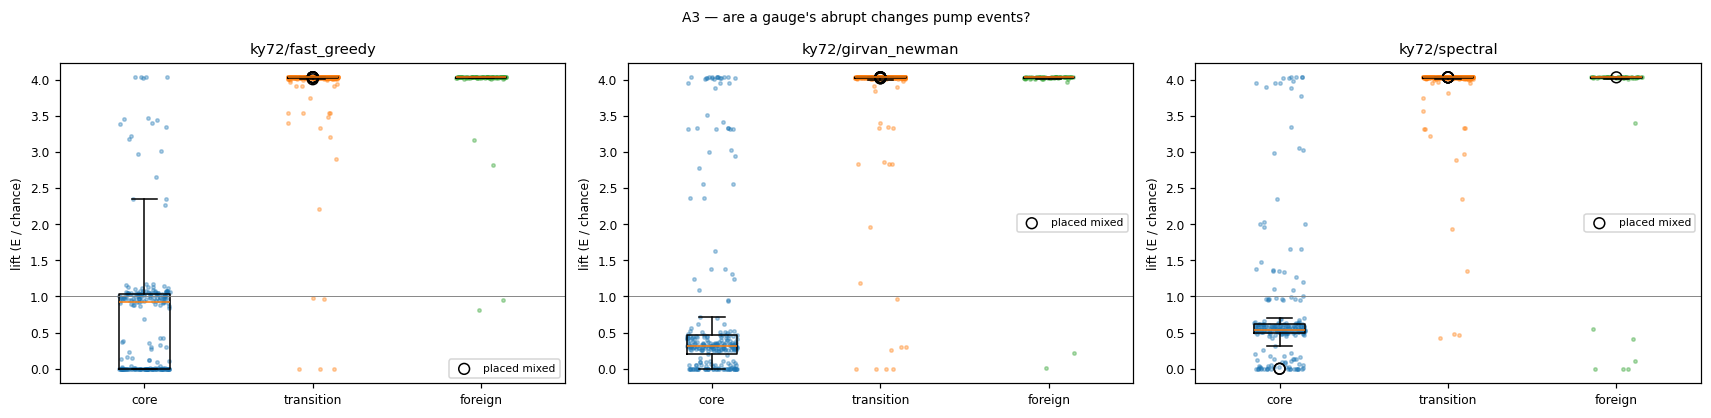

In [9]:
EV = A["event"]
G = (EV.groupby(["network", "districting", "id", "home", "tier", "placed"])
     .agg(lift=("lift", "median"), E=("E", "median"), chance=("chance", "median"),
          lift_pump=("lift_pump", lambda s: s.dropna().mode().iat[0] if s.notna().any() else None),
          pump_agree=("lift_pump", lambda s: float((s == s.dropna().mode().iat[0]).mean())
                      if s.notna().any() else np.nan),
          records=("world", "nunique")).reset_index())
display(Markdown("**By tier** — median lift, and share of gauges with lift > 2"))
display(G.groupby(["network", "districting", "tier"])
        .agg(n=("id", "size"), lift_med=("lift", "median"),
             lift_q10=("lift", lambda s: s.quantile(.1)), lift_q90=("lift", lambda s: s.quantile(.9)),
             share_gt2=("lift", lambda s: float((s > 2).mean())), chance=("chance", "median"))
        .round(3))
display(Markdown("**Which pump drives which gauges** — gauges with lift > 2, by home district "
                 "(`pump_agree` = share of records naming the same pump)"))
display(pd.crosstab([G.loc[G["lift"] > 2, "districting"], G.loc[G["lift"] > 2, "home"]],
                    G.loc[G["lift"] > 2, "lift_pump"]))
display(Markdown("**Placed gauges**"))
display(G[G["placed"] != ""].sort_values(["districting", "placed", "home"]).round(3)
        .reset_index(drop=True))

parts = G[["network", "districting"]].drop_duplicates().itertuples(index=False)
parts = list(parts)
fig, axes = plt.subplots(1, len(parts), figsize=(5.2 * len(parts), 3.8), squeeze=False)
for ax, (net, meth) in zip(axes[0], parts):
    g = G[(G["network"] == net) & (G["districting"] == meth)]
    tiers = [t for t in ("core", "transition", "foreign", "unusable") if (g["tier"] == t).any()]
    ax.boxplot([g.loc[g["tier"] == t, "lift"].dropna() for t in tiers], labels=tiers, showfliers=False)
    for x, t in enumerate(tiers, 1):
        v = g.loc[g["tier"] == t, "lift"].dropna()
        ax.scatter(np.full(len(v), x) + np.random.default_rng(0).uniform(-.15, .15, len(v)), v,
                   s=5, alpha=.35)
    pm = g[g["placed"].str.contains("mixed")]
    ax.scatter([tiers.index(t) + 1 for t in pm["tier"]], pm["lift"], s=50, facecolors="none",
               edgecolors="k", label="placed mixed")
    ax.axhline(1, color="0.5", lw=0.6)
    ax.set(title=f"{net}/{meth}", ylabel="lift (E / chance)")
    ax.legend(fontsize=7)
fig.suptitle("A3 — are a gauge's abrupt changes pump events?", fontsize=9)
fig.tight_layout(); plt.show()

### A4 — lag structure on anomalies (every flow gauge, every world, both windows)

The weekly cycle is shared by every series, so cross-correlating raw series finds the shape, not a
delay. Each series is first reduced to its **anomaly**: minus its own weekly profile on the window (tiled
by weekday and step) and minus a linear trend — what is left is the day-to-day variation (weather, volume
draw, crowd residual). Then, per gauge $s$ and driver $x$,
$r_{s,x}(\tau)=\operatorname{corr}\big(e_s(t),\,e_x(t-\tau)\big)$ for $\lvert\tau\rvert\le$ `LAG_H`, and
$\tau^\*=\arg\max_\tau\lvert r_{s,x}(\tau)\rvert$ ($\tau^\*>0$: the gauge lags the driver).

| column | driver $x$ | reading |
|---|---|---|
| `tau_home_h`, `r_home_peak`, `r_home_0` | the gauge's home district demand | demand-fed: $\tau^\*=0$, $r$ high |
| `tau_total_h`, `r_total_*` | total demand | storage link: $\tau^\*\neq0$ is the precedence causality needs |
| `tau_tank_h`, `r_tank_*` | net inflow of the most active tank | storage link: $\tau^\*\approx0$, $\lvert r\rvert$ high (mechanism check — flow *is* exchange) |
| `anom_ratio`, `drv_anom_home` | sd(anomaly)/sd(series), gauge and home demand | small = little day-to-day variation to correlate; read `r` with this beside it |

**Read with care.** If `drv_anom_home` is small the demand model carries little day-to-day variation and
every $r$ here is weak by construction — that is a finding about the generator, not about the gauges.
A peak at $\tau^\*$ far from 0 with $\lvert r\rvert$ barely above $\lvert r(0)\rvert$ is not a lag.

**By tier** — medians over gauges of the per-gauge medians; `share_lag` = |τ\*| ≥ 1 h

n  tau_home  r_home_peak  r_home_0  share_lag_home  tau_total  r_total_peak  r_total_0  share_lag_total  tau_tank  r_tank_peak  r_tank_0  share_lag_tank  anom_ratio  drv_anom_home
network districting   tier                                                                                                                                                                                             
ky72    fast_greedy   core        229       0.0        0.113     0.111           0.314        0.0         0.064      0.053            0.563       7.0        0.028     0.005           0.856       0.201          0.025
                      foreign      91       6.5        0.041     0.023           0.901        6.0         0.048      0.023            0.835       0.0        0.956     0.956           0.033       0.138          0.028
                      transition  283       0.0        0.060     0.047           0.516        3.5         0.059      0.022            0.859       0.0        0.867     0.867           0.131       0.153          0.028
        girvan_newman core        253       0.0        0.108     0.112           0.312        0.0         0.070      0.057            0.518       2.0        0.030     0.006           0.771       0.210          0.023
                      foreign      61       6.0        0.109     0.028           1.000        6.0         0.122      0.048            0.984       0.0        0.926     0.926           0.033       0.185          0.023
                      transition  289       6.0        0.101     0.035           0.862        6.0         0.118      0.046            0.952       0.0        0.922     0.922           0.076       0.188          0.023
        spectral      core        241       0.0        0.098     0.094           0.390        0.0         0.068      0.057            0.502       2.0        0.027     0.007           0.793       0.222          0.023
                      foreign      55       1.0        0.042     0.015           0.909        0.0         0.060      0.024            0.891       0.0        0.939     0.939           0.055       0.166          0.022
                      transition  307       0.0        0.042     0.026           0.629        0.0         0.056      0.023            0.879       0.0        0.899     0.899           0.085       0.161          0.022

**Placed gauges**

,network,districting,id,home,tier,placed,anom_ratio,tau_home_h,r_home_peak,r_home_0,tau_total_h,r_total_peak,r_total_0,tau_tank_h,r_tank_peak,r_tank_0,drv_anom_home
0,ky72,fast_greedy,q_P-191,District_A,transition,mixed,0.196,0.0,0.047,0.047,3.0,-0.053,0.003,0.0,-0.647,-0.647,0.028
1,ky72,fast_greedy,q_P-288,District_A,transition,mixed,0.130,0.0,-0.099,-0.099,0.0,-0.075,-0.075,0.0,0.933,0.933,0.028
2,ky72,fast_greedy,q_P-164,District_B,transition,mixed,0.159,-0.5,-0.058,-0.058,-3.0,0.057,-0.031,0.0,0.843,0.843,0.025
3,ky72,fast_greedy,q_P-617,District_B,transition,mixed,0.167,0.0,0.068,0.068,-15.0,-0.044,0.043,0.0,-0.856,-0.856,0.025
4,ky72,fast_greedy,q_P-10,District_C,transition,mixed,0.115,0.5,-0.083,-0.076,0.0,-0.091,-0.091,0.0,0.958,0.958,0.019
5,ky72,fast_greedy,q_P-267,District_C,transition,mixed,0.134,0.0,-0.028,-0.028,7.5,-0.046,0.021,0.0,-0.974,-0.974,0.019
6,ky72,fast_greedy,q_P-246,District_D,transition,mixed,0.135,0.0,-0.075,-0.075,0.5,-0.040,-0.026,0.0,0.963,0.963,0.044
7,ky72,fast_greedy,q_P-537,District_D,transition,mixed,0.120,0.0,-0.121,-0.121,0.0,-0.061,-0.046,0.0,0.947,0.947,0.044
8,ky72,fast_greedy,q_P-467,District_A,core,pure,0.146,0.0,0.119,0.119,-8.5,0.057,0.048,32.0,0.023,-0.009,0.028
9,ky72,fast_greedy,q_P-499,District_A,core,pure,0.113,0.0,0.205,0.205,0.0,0.068,0.061,16.0,-0.016,-0.004,0.028


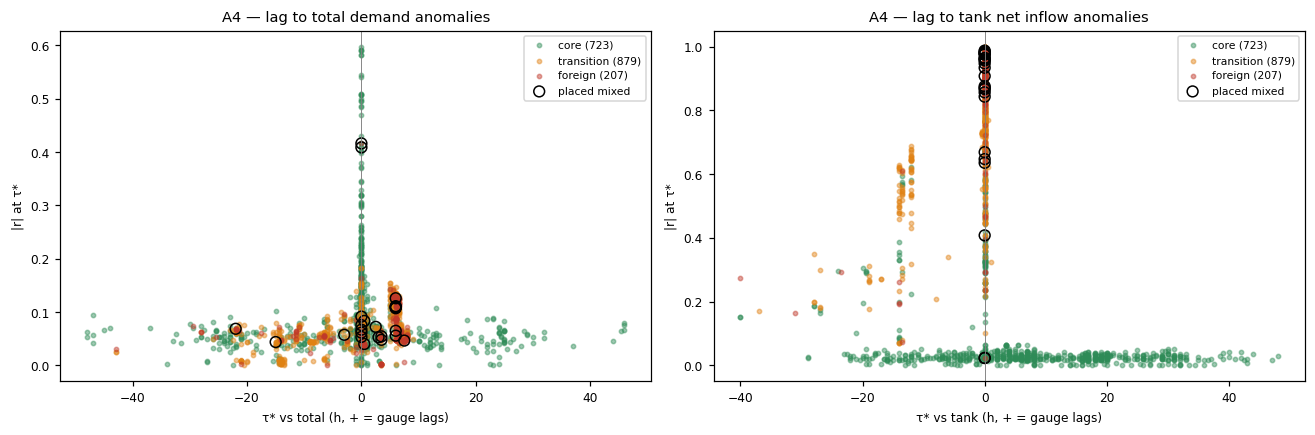

In [10]:
LG = A["lag"]
num = [c for c in LG.columns if c.startswith(("tau_", "r_", "anom_", "drv_"))]
GL = (LG.groupby(["network", "districting", "id", "home", "tier", "placed"])[num].median()
      .reset_index())
display(Markdown("**By tier** — medians over gauges of the per-gauge medians; `share_lag` = |τ\\*| ≥ 1 h"))
agg = {"n": ("id", "size")}
for key in ("home", "total", "tank"):
    if f"tau_{key}_h" in GL:
        agg[f"tau_{key}"] = (f"tau_{key}_h", "median")
        agg[f"r_{key}_peak"] = (f"r_{key}_peak", lambda s: s.abs().median())
        agg[f"r_{key}_0"] = (f"r_{key}_0", lambda s: s.abs().median())
        agg[f"share_lag_{key}"] = (f"tau_{key}_h", lambda s: float((s.abs() >= 1).mean()))
agg["anom_ratio"] = ("anom_ratio", "median")
agg["drv_anom_home"] = ("drv_anom_home", "median")
display(GL.groupby(["network", "districting", "tier"]).agg(**agg).round(3))
display(Markdown("**Placed gauges**"))
display(GL[GL["placed"] != ""].sort_values(["districting", "placed", "home"]).round(3)
        .reset_index(drop=True))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.0))
for ax, key in zip(axes, ("total", "tank")):
    if f"tau_{key}_h" not in GL:
        ax.axis("off"); continue
    for tier, colour in (("core", "#2e8b57"), ("transition", "#e08214"), ("foreign", "#c0392b")):
        g = GL[GL["tier"] == tier]
        ax.scatter(g[f"tau_{key}_h"], g[f"r_{key}_peak"].abs(), s=8, alpha=.45, c=colour,
                   label=f"{tier} ({len(g)})")
    pm = GL[GL["placed"].str.contains("mixed")]
    ax.scatter(pm[f"tau_{key}_h"], pm[f"r_{key}_peak"].abs(), s=50, facecolors="none",
               edgecolors="k", label="placed mixed")
    ax.axvline(0, color="0.5", lw=0.6)
    ax.set(xlabel=f"τ* vs {key} (h, + = gauge lags)", ylabel="|r| at τ*",
           title=f"A4 — lag to {'total demand' if key == 'total' else 'tank net inflow'} anomalies")
    ax.legend(fontsize=7)
fig.tight_layout(); plt.show()

# Block T — the transition months (and block B on them)

Every analysis so far compared two **stationary** windows (init vs settled) and threw away the months in
between. Those months are the only time-resolved, **exogenous** excitation on disk: node conversions are
scheduled (`gt_drift_schedule`), each node blends linearly from its old to its new regime over
`drift_ramp_days` starting at the first step of its `drift_month`, and nothing else in the world changes.

**Multi-hub revision.** The first version followed one pump and one tank — harmless on KY7 (one pump,
one active tank), blind on D-Town, where each drift moves its own subset of pumps. Every test below now
runs **per active pump and per active tank**, and the decomposition is classified on quantities that
stay meaningful when pump and tank flows span the district demands (they do on D-Town, by mass balance).

| test | question |
|---|---|
| T1 dose–response, per pump | month by month, does each pump follow a quasi-static map — and which drifts move which pump? |
| T1 signatures | can the drifting district be told apart from the pumps it moves? |
| T2 distributed lag, per pump / tank | after a cohort switches, does each pump / tank respond the same day or later? |
| B1 decomposition | per gauge, what demand explains, and what storage explains that demand cannot |
| B2 partition invariance | is storage linkage a property of the link? (needs ≥ 2 partitions in the study) |
| B3 independent indicators | does the decomposition agree with per-pump lift, sign alternation, distance to the storage hubs? |
| B4 distributions | where would class boundaries go — reported, not tuned |

**Active** means: a pump with any on-step in the record; a tank whose net-inflow sd is at least 10% of the
largest tank's (KY7: T-3 only; D-Town: all but the near-static ones). Pump links are excluded from the
gauge population. One compute pass; **run block A first** (B3 joins A3's per-pump lift).

In [11]:
import networkx as nx

PRE_D = 14          # T2: baseline days before a cohort onset (2 per weekday)
POST_D = None       # T2: days after onset; None -> days_per_month - 1 (before the next cohort)
LAGS_D = 5          # T2: distributed-lag terms k = 0..LAGS_D days
LEADS_D = 3         # T2: placebo lead terms k = -LEADS_D..-1 (future demand must not predict)
TANK_ACTIVE = 0.10  # tank active if its net-inflow sd >= this share of the largest tank's


def daily(x, sd):
    x = np.asarray(x, float)
    x = x if x.ndim > 1 else x[:, None]
    n = (x.shape[0] // sd) * sd
    return x[:n].reshape(-1, sd, x.shape[1]).mean(axis=1)


def daily_sd(x, sd):
    x = np.asarray(x, float)
    x = x if x.ndim > 1 else x[:, None]
    n = (x.shape[0] // sd) * sd
    return x[:n].reshape(-1, sd, x.shape[1]).std(axis=1)


def daily_switch_tod(on, sd, hours, up=True):
    d = np.diff(on.astype(int), prepend=on[0])
    hit = d == (1 if up else -1)
    n = (len(on) // sd) * sd
    H = hit[:n].reshape(-1, sd)
    first = np.where(H.any(axis=1), H.argmax(axis=1), -1)
    return np.where(first >= 0, first * hours, np.nan)


def weekday_adjusted(v, d0, pre_d, lags, circular=False):
    # v (n_days,) -> change at d0+lags against the same weekday in the pre_d days before d0
    pre, days = np.arange(d0 - pre_d, d0), d0 + lags
    if circular:
        base = []
        for w in range(7):
            b = v[pre[(pre % 7) == w]]
            base.append(circ_mean_h(b[~np.isnan(b)]))
        return np.array([circ_diff_h(v[d], base[d % 7]) if not np.isnan(v[d]) else np.nan
                         for d in days])
    base = np.array([np.nanmean(v[pre[(pre % 7) == w]]) if ((pre % 7) == w).any() else np.nan
                     for w in range(7)])
    return v[days] - base[days % 7]


def distributed_lag(x, Dtot, onsets, post, circular=False):
    # Pooled over cohorts: dx_e(t) = c + sum_k g_k dD_e(t-k), k = -LEADS_D..LAGS_D.
    # dD and dx are weekday-adjusted changes after onset, so the cohort's own change of weekly
    # shape enters dD and is not mistaken for a lag. Returns dict or None.
    lags = np.arange(-PRE_D, post + 1)
    ks = np.arange(-LEADS_D, LAGS_D + 1)
    rows_y, rows_X = [], []
    n_ev = 0
    for d0 in onsets:
        if d0 - PRE_D < 0 or d0 + post >= len(Dtot):
            continue
        dx = weekday_adjusted(x, d0, PRE_D, lags, circular)
        dd = weekday_adjusted(Dtot, d0, PRE_D, lags)
        n_ev += 1
        for i_t, t in enumerate(lags):
            idx = i_t - ks                                  # dD(t - k)
            if idx.min() < 0 or idx.max() >= len(lags) or np.isnan(dx[i_t]):
                continue
            reg = dd[idx]
            if np.isnan(reg).any():
                continue
            rows_y.append(dx[i_t]); rows_X.append(reg)
    if n_ev < 2 or len(rows_y) < 3 * len(ks):
        return None
    y = np.array(rows_y)
    X = np.column_stack([np.ones(len(y)), np.array(rows_X)])
    B, *_ = np.linalg.lstsq(X, y, rcond=None)
    res = y - X @ B
    dof = max(len(y) - X.shape[1], 1)
    s2 = (res @ res) / dof
    cov = s2 * np.linalg.pinv(X.T @ X)
    g = B[1:]
    cg = cov[1:, 1:]
    lag_k, lead_k = ks >= 0, ks < 0
    tot = g[lag_k].sum()
    se_tot = float(np.sqrt(np.ones(lag_k.sum()) @ cg[np.ix_(lag_k, lag_k)] @ np.ones(lag_k.sum())))
    tss = ((y - y.mean()) ** 2).sum()
    return {"n_events": n_ev, "n_rows": len(y), "g": g, "ks": ks,
            "gain": tot, "t_gain": tot / se_tot if se_tot > 0 else np.nan,
            "g0_share": g[ks == 0][0] / tot if tot != 0 else np.nan,
            "centroid_d": float((ks[lag_k] * g[lag_k]).sum() / tot) if tot != 0 else np.nan,
            "lead_share": float(np.abs(g[lead_k]).sum() / max(np.abs(g).sum(), 1e-24)),
            "R2": 1.0 - (res @ res) / tss if tss > 0 else np.nan}


def adj_r2_cols(Y, X):
    B, *_ = np.linalg.lstsq(X, Y, rcond=None)
    res = ((Y - X @ B) ** 2).sum(axis=0)
    tot = ((Y - Y.mean(axis=0)) ** 2).sum(axis=0)
    n, p = X.shape[0], X.shape[1] - 1
    r2 = np.where(tot > 1e-12, 1.0 - res / np.where(tot > 1e-12, tot, 1.0), np.nan)
    return 1.0 - (1.0 - r2) * (n - 1) / max(n - p - 1, 1)


def hub_distance(wn, tanks, pumps):
    # hop distance of every link to the nearest storage hub (active tanks, active pumps' end nodes)
    G = wn.to_graph().to_undirected()
    src = set(tanks) | {n for p in pumps for n in (wn.get_link(p).start_node_name,
                                                   wn.get_link(p).end_node_name)}
    dist = nx.multi_source_dijkstra_path_length(G, src, weight=lambda u, v, d: 1)
    out = {}
    for ln in wn.link_name_list:
        l = wn.get_link(ln)
        out[ln] = min(dist.get(l.start_node_name, np.inf), dist.get(l.end_node_name, np.inf))
    return out


def analyse_transition(P, wins, wn, M, meta, out):
    pumps, tanks = storage_map(wn, P.flows.columns)
    hours, sd, sm = float(P.time["resolution_h"]), P.steps_day, P.steps_month
    dpm, n_m = int(P.time["days_per_month"]), int(P.time["n_months"])
    names = P.names
    els = M["element"].astype(str).tolist()
    S = storage_series(P, pumps, tanks)
    ON = {p: pump_on(P.flows[p].to_numpy(float)) for p in pumps}
    act_p = [p for p in pumps if ON[p].any()]
    tsd = {t: S[f"tank:{t}"].std() for t in tanks}
    act_t = [t for t in tanks if tsd[t] >= TANK_ACTIVE * max(tsd.values(), default=0) and tsd[t] > 0]
    LEV = {t: (P.pressures[t].to_numpy(float) if t in P.pressures.columns
               else np.cumsum(S[f"tank:{t}"].to_numpy(float))) for t in act_t}
    dd = P.district_demand[names].to_numpy(float)
    tot = dd.sum(axis=1)
    drift = meta["drift"]
    kd = names.index(drift) if drift in names else None
    first = int(P.phases()["init"][1])
    (i0, i1), (f0, f1) = wins
    ramp = int((P.params.get("patterns") or {}).get("drift_ramp_days", 0))
    meta = {**meta, "first_month": first, "settled_month": f0 // sm, "ramp_days": ramp,
            "days_per_month": dpm, "active_pumps": ",".join(act_p), "active_tanks": ",".join(act_t)}
    out["hub"].append({**meta, "pumps": act_p, "tanks": act_t})

    # ---- T1: month by month, per pump and per tank --------------------------------------
    init_tot = tot[i0:i1].mean()
    init_drift = dd[i0:i1, kd].mean() if kd is not None else np.nan
    for m in range(n_m):
        lo, hi = m * sm, (m + 1) * sm
        base = {**meta, "month": m,
                "phase": ("init" if m < first else "settled" if lo >= f0 else "transition"),
                "dD_total": tot[lo:hi].mean() / init_tot - 1.0,
                "dD_drift": dd[lo:hi, kd].mean() / init_drift - 1.0 if kd is not None else np.nan}
        for p in act_p:
            o = ON[p][lo:hi]
            dsw = np.diff(o.astype(int))
            se = np.flatnonzero(np.diff(np.r_[0, o.astype(int), 0]) != 0).reshape(-1, 2)
            out["month"].append({**base, "unit": p, "kind": "pump", "duty": float(o.mean()),
                                 "mean_on_h": float((se[:, 1] - se[:, 0]).mean() * hours) if len(se) else np.nan,
                                 "on_tod": circ_mean_h(((np.where(dsw == 1)[0] + 1 + lo) % sd) * hours)})
        for t in act_t:
            L_ = LEV[t][lo:hi]
            nd = len(L_) // sd
            out["month"].append({**base, "unit": t, "kind": "tank",
                                 "tank_mean": float(L_.mean()),
                                 "tank_amp": float(np.ptp(L_[:nd * sd].reshape(nd, sd), axis=1).mean())})

    # ---- T2: distributed lag on the scheduled cohorts, per pump / tank feature ---------
    sch = P.schedule
    cohorts = sorted({int(m) for m, n in zip(sch["drift_month"], sch["node"].astype(str))
                      if n in P.demand.columns and int(m) > 0})
    onsets = [m * dpm for m in cohorts]
    post = (dpm - 1) if POST_D is None else int(POST_D)
    Dd = daily(tot, sd)[:, 0]
    feats = []
    for p in act_p:
        feats += [(p, "pump", "on_h", daily(ON[p].astype(float), sd)[:, 0] * 24.0, False),
                  (p, "pump", "on_tod", daily_switch_tod(ON[p], sd, hours, True), True),
                  (p, "pump", "off_tod", daily_switch_tod(ON[p], sd, hours, False), True)]
    for t in act_t:
        feats += [(t, "tank", "level_mean", daily(LEV[t], sd)[:, 0], False),
                  (t, "tank", "level_sd", daily_sd(LEV[t], sd)[:, 0], False)]
    if kd is not None:
        feats.append(("D_drift", "demand", "daily_mean", daily(dd[:, kd], sd)[:, 0], False))
    feats.append(("D_total", "demand", "daily_mean", Dd, False))
    for unit, kind, feat, x, circ in feats:
        r = distributed_lag(x, Dd, onsets, post, circ)
        row = {**meta, "n_cohorts": len(cohorts), "unit": unit, "kind": kind, "feature": feat}
        if r is None:
            out["dlag"].append({**row, "n_events": 0}); continue
        out["dlag"].append({**row, **{k_: v for k_, v in r.items() if k_ not in ("g", "ks")}})
        for k_, g_ in zip(r["ks"], r["g"]):
            out["dlag_g"].append({**row, "k_d": int(k_), "g": g_,
                                  "g_norm": g_ / r["gain"] if r["gain"] else np.nan,
                                  "t_gain": r["t_gain"]})

    # ---- B1: decomposition over the transition span (hourly, raw) ------------------
    lo, hi = max(first - 1, 0) * sm, f0
    Y = P.flows[els].to_numpy(float)[lo:hi]
    one = np.ones((hi - lo, 1))
    Xd = np.column_stack([one, dd[lo:hi]])
    Sx = S.to_numpy(float)[lo:hi]
    Xs = np.column_stack([one, Sx])
    Xf = np.column_stack([Xd, Sx])
    r2d, r2s, r2f = adj_r2_cols(Y, Xd), adj_r2_cols(Y, Xs), adj_r2_cols(Y, Xf)
    phi = np.array([opposite_share(Y[:, i]) for i in range(Y.shape[1])])
    for i, g in M.reset_index(drop=True).iterrows():
        Ud, Us = r2f[i] - r2s[i], r2f[i] - r2d[i]
        out["decomp"].append({**meta, "id": g["id"], "element": str(g["element"]),
                              "home": g["home"], "tier": g["tier"], "placed": g["placed"],
                              "R2_dem": r2d[i], "R2_sto": r2s[i], "R2_full": r2f[i],
                              "U_d": Ud, "U_s": Us, "shared": r2f[i] - Ud - Us, "phi": phi[i],
                              "storage": bool(Us > r2d[i]), "n_steps": hi - lo})


TB = {k: [] for k in ("month", "dlag", "dlag_g", "decomp", "hub")}
issues, hubdist = [], {}
paths = stack_paths(WORLDS)
for si, (path, sims) in enumerate(paths.items()):
    L_ = store.load_stack(path, with_probes=True)
    settle = L_.spec["probe"]["settle"]
    wn = ATLAS.world(sims[0]).network_model
    placed = {}
    for h in sims:
        PL = ATLAS.world(h).catalog.load("sensor_placement")
        for _, g in PL[PL["kind"] == FLOW].iterrows():
            placed.setdefault(g["sensor"], set()).add(g["slot_class"])
    M = L_.mixture[L_.mixture["kind"] == FLOW][["id", "element", "home", "tier"]].copy()
    M["placed"] = M["id"].map(lambda i: "/".join(sorted(placed.get(i, []))))
    M = M[~M["element"].astype(str).isin(set(wn.pump_name_list))]   # pumps are not meters
    base = {"network": L_.network, "districting": L_.method, "stack": L_.stack_hash[:6]}
    jobs = [("probe", k, None) for k in sorted(L_.probes)] + [("target", None, h) for h in sims]
    for source, k, h in jobs:
        try:
            if source == "probe":
                P = L_.probes[k]
                wins = stack_windows(P, settle)
                meta = {**base, "source": "probe", "world": f"probe:{k}", "drift": k}
            else:
                w = ATLAS.world(h)
                P = target_probe(w, with_pressures=True)
                wins = target_windows(P, w.params["sensor_placement"]["probe"]["settle"],
                                      w.params["patterns"])
                meta = {**base, "source": "target", "world": h[:8], "drift": P.drift["tgt_district"]}
            Mi = M[M["element"].astype(str).isin(P.flows.columns)]
            analyse_transition(P, wins, wn, Mi, meta, TB)
        except Exception as exc:                          # reported, never swallowed silently
            issues.append({**base, "source": source, "world": k or h,
                           "issue": f"{type(exc).__name__}: {exc}"[:200]})
        print(f"\r  block T/B: stack {si + 1}/{len(paths)} — {source} {k or h[:8]}      ",
              end="", flush=True)
    if L_.network not in hubdist and TB["hub"]:
        hp = [r_ for r_ in TB["hub"] if r_["network"] == L_.network]
        hubdist[L_.network] = hub_distance(wn, sorted({t for r_ in hp for t in r_["tanks"]}),
                                           sorted({p for r_ in hp for p in r_["pumps"]}))
    del L_
print()
TB = {k: pd.DataFrame(v) for k, v in TB.items()}
if issues:
    display(Markdown("**Records not analysed**")); display(pd.DataFrame(issues))
display(TB["hub"].drop(columns=["pumps", "tanks"])
        [["districting", "source", "world", "drift", "first_month", "settled_month", "ramp_days",
          "days_per_month", "active_pumps", "active_tanks"]].reset_index(drop=True))
if (TB["hub"]["ramp_days"] >= TB["hub"]["days_per_month"]).any():
    print("!! drift_ramp_days >= days_per_month in some worlds: consecutive cohorts' ramps overlap")

  block T/B: stack 3/3 — target d767277b       


,districting,source,world,drift,first_month,settled_month,ramp_days,days_per_month,active_pumps,active_tanks
0,fast_greedy,probe,probe:District_A,District_A,12,57,7,21,~@Pump-1,T-3
1,fast_greedy,probe,probe:District_B,District_B,12,50,7,21,~@Pump-1,T-3
2,fast_greedy,probe,probe:District_C,District_C,12,35,7,21,~@Pump-1,T-3
3,fast_greedy,probe,probe:District_D,District_D,12,27,7,21,~@Pump-1,T-3
4,fast_greedy,target,0b4750d3,District_A,12,51,7,21,~@Pump-1,T-3
5,fast_greedy,target,13f0f426,District_B,12,35,7,21,~@Pump-1,T-3
6,fast_greedy,target,312ef90c,District_C,12,32,7,21,~@Pump-1,T-3
7,fast_greedy,target,8a9b36d7,District_D,12,33,7,21,~@Pump-1,T-3
8,girvan_newman,probe,probe:District_A,District_A,12,60,7,21,~@Pump-1,T-3
9,girvan_newman,probe,probe:District_B,District_B,12,33,7,21,~@Pump-1,T-3


### T1 — dose–response per pump, month by month, and the drift signatures

Per world, active pump $p$ and month $m$: $\Delta\bar D_{\text{tot}}(m)=\bar D_{\text{tot}}(m)/\bar D_{\text{tot}}^{\text{init}}-1$
and $\Delta\text{duty}_p(m)=\text{duty}_p(m)-\text{duty}_p^{\text{init}}$. The pump's quasi-static map in that world is
the slope through its settled months, $s_p=\overline{\Delta\text{duty}_p}_{\text{settled}}/\overline{\Delta\bar D}_{\text{settled}}$,
and the transition residual is $e_p(m)=\Delta\text{duty}_p(m)-s_p\,\Delta\bar D_{\text{tot}}(m)$.

| column | definition | reading |
|---|---|---|
| `d_duty_settled` | settled Δduty of the pump | ≈ 0 = this drift does not reach this pump |
| `slope` | $s_p$ | the pump's quasi-static gain under this drift |
| `resid_mean`, `resid_rms_rel` | mean / RMS of $e_p(m)$ over transition months (RMS relative to $\lvert$`d_duty_settled`$\rvert$) | ≈ 0 = quasi-static at month scale; only read where `d_duty_settled` is material |
| `duty_max` | max monthly duty | ≈ 1 = pump saturated |

**Signatures.** Each drift $k$ moves the pumps by the vector $v_k=(\Delta\text{duty}_p)_p$ (settled, per unit
$\lvert\Delta\bar D_{\text{tot}}\rvert$, signed). The cosine $\cos(v_k,v_j)$ asks whether two drifts are told
apart **by which pumps they move and in which direction**: ≈ 1 = indistinguishable through storage (only
the magnitude differs); ≈ 0 = disjoint pump sets; < 0 = opposite. Magnitude is deliberately left out —
it is the drift's size, not its location.

**Settled Δduty per pump** — rows: drift (probe / target); columns: pump

pump                                     ~@Pump-1
network districting   drift      source          
ky72    fast_greedy   District_A probe      0.133
                                 target     0.134
                      District_B probe      0.130
                                 target     0.132
                      District_C probe     -0.073
                                 target    -0.072
                      District_D probe     -0.059
                                 target    -0.060
        girvan_newman District_A probe      0.294
                                 target     0.298
                      District_B probe      0.120
                                 target     0.119
                      District_C probe     -0.047
                                 target    -0.047
                      District_D probe     -0.029
                                 target    -0.029
        spectral      District_A probe      0.235
                                 target     0.240
                      District_B probe      0.196
                                 target     0.199
                      District_C probe     -0.024
                                 target    -0.023
                      District_D probe     -0.076
                                 target    -0.076

**Quasi-static check** — only pumps the drift actually moves (|Δduty| ≥ 0.02)

,network,districting,source,world,drift,pump,n_transition,dD_total_settled,d_duty_settled,slope,resid_mean,resid_rms_rel,duty_max
0,ky72,fast_greedy,probe,probe:District_A,District_A,~@Pump-1,45,0.256,0.133,0.519,-0.000,0.039,0.690
1,ky72,fast_greedy,target,0b4750d3,District_A,~@Pump-1,39,0.255,0.134,0.527,-0.001,0.037,0.694
2,ky72,fast_greedy,probe,probe:District_B,District_B,~@Pump-1,38,0.251,0.130,0.519,-0.000,0.040,0.688
3,ky72,fast_greedy,target,13f0f426,District_B,~@Pump-1,23,0.251,0.132,0.525,-0.001,0.026,0.690
4,ky72,fast_greedy,probe,probe:District_C,District_C,~@Pump-1,23,-0.126,-0.073,0.580,0.002,0.099,0.579
5,ky72,fast_greedy,target,312ef90c,District_C,~@Pump-1,20,-0.125,-0.072,0.572,0.002,0.107,0.577
6,ky72,fast_greedy,probe,probe:District_D,District_D,~@Pump-1,15,-0.141,-0.059,0.417,-0.006,0.158,0.579
7,ky72,fast_greedy,target,8a9b36d7,District_D,~@Pump-1,21,-0.143,-0.060,0.421,-0.002,0.124,0.577
8,ky72,girvan_newman,probe,probe:District_A,District_A,~@Pump-1,48,0.528,0.294,0.558,0.008,0.037,0.849
9,ky72,girvan_newman,target,35d8d9bc,District_A,~@Pump-1,42,0.533,0.298,0.558,0.010,0.042,0.851


**Signature cosine between drifts** (probe and target averaged per drift)

...

drift,District_A,District_B,District_C,District_D
drift,,,,
District_A,1.0,1.0,-1.0,-1.0
District_B,1.0,1.0,-1.0,-1.0
District_C,-1.0,-1.0,1.0,1.0
District_D,-1.0,-1.0,1.0,1.0


*ky72/girvan_newman*

drift,District_A,District_B,District_C,District_D
drift,,,,
District_A,1.0,1.0,-1.0,-1.0
District_B,1.0,1.0,-1.0,-1.0
District_C,-1.0,-1.0,1.0,1.0
District_D,-1.0,-1.0,1.0,1.0


*ky72/spectral*

drift,District_A,District_B,District_C,District_D
drift,,,,
District_A,1.0,1.0,-1.0,-1.0
District_B,1.0,1.0,-1.0,-1.0
District_C,-1.0,-1.0,1.0,1.0
District_D,-1.0,-1.0,1.0,1.0


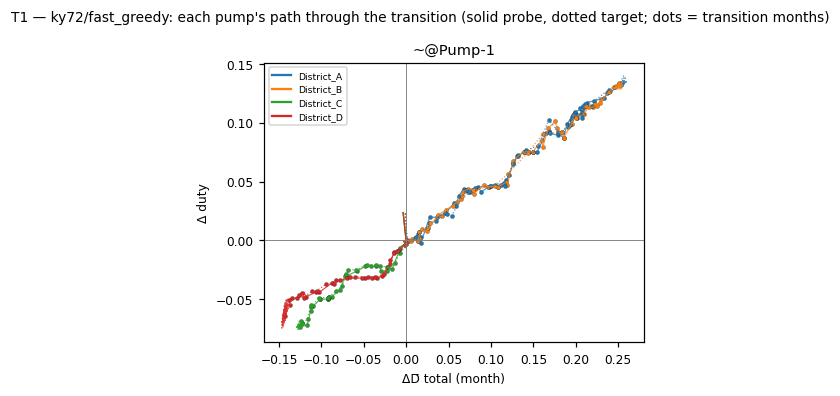

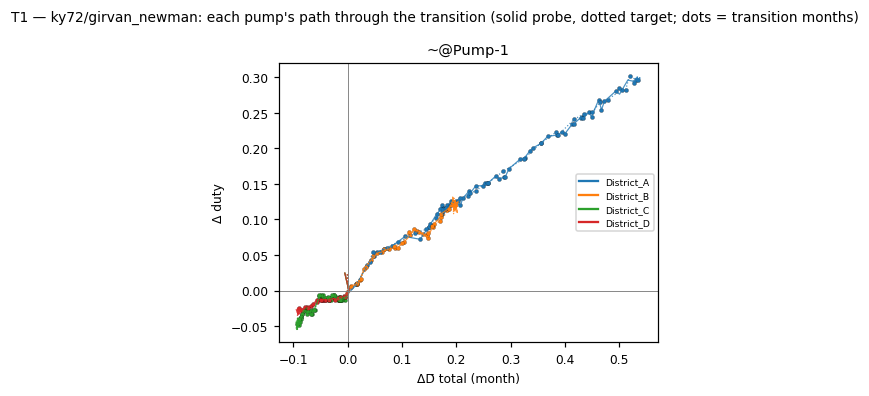

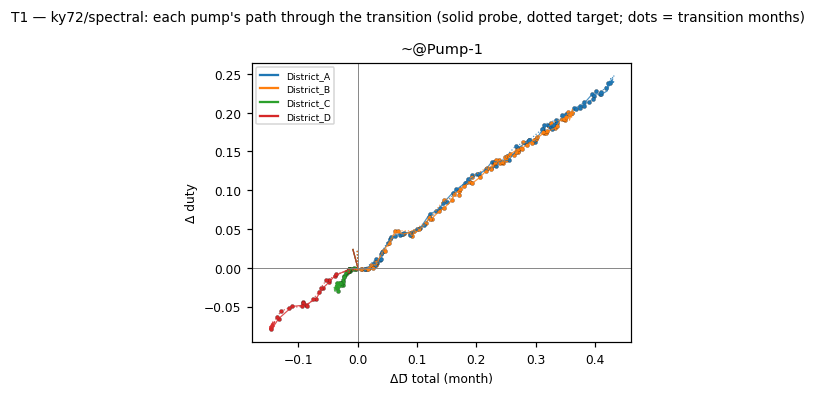

In [12]:
MO = TB["month"]
MP = MO[MO["kind"] == "pump"].copy()
rows = []
for key, g in MP.groupby(["network", "districting", "source", "world", "drift", "unit"]):
    g = g.sort_values("month")
    d = g.assign(d_duty=g["duty"] - g.loc[g["phase"] == "init", "duty"].mean())
    st, tr = d[d["phase"] == "settled"], d[d["phase"] == "transition"]
    dDs, dus = st["dD_total"].mean(), st["d_duty"].mean()
    s = dus / dDs if abs(dDs) > 1e-9 else np.nan
    e = tr["d_duty"] - s * tr["dD_total"]
    rows.append(dict(zip(["network", "districting", "source", "world", "drift", "pump"], key),
                     n_transition=len(tr), dD_total_settled=dDs, d_duty_settled=dus, slope=s,
                     resid_mean=e.mean(),
                     resid_rms_rel=np.sqrt((e ** 2).mean()) / max(abs(dus), 1e-9),
                     duty_max=g["duty"].max()))
T1 = pd.DataFrame(rows)
display(Markdown("**Settled Δduty per pump** — rows: drift (probe / target); columns: pump"))
display(T1.pivot_table(index=["network", "districting", "drift", "source"], columns="pump",
                       values="d_duty_settled").round(3))
display(Markdown("**Quasi-static check** — only pumps the drift actually moves (|Δduty| ≥ 0.02)"))
display(T1[T1["d_duty_settled"].abs() >= 0.02]
        .sort_values(["districting", "drift", "pump", "source"]).round(3).reset_index(drop=True))

display(Markdown("**Signature cosine between drifts** (probe and target averaged per drift)"))
for (net, meth), g in T1.groupby(["network", "districting"]):
    V = (g.assign(v=g["d_duty_settled"] / g["dD_total_settled"].abs())
         .pivot_table(index="drift", columns="pump", values="v", aggfunc="mean").fillna(0.0))
    Vn = V.div(np.sqrt((V ** 2).sum(axis=1)).replace(0, np.nan), axis=0)
    display(Markdown(f"*{net}/{meth}*"))
    display((Vn @ Vn.T).round(2))

for (net, meth), g in MP.groupby(["network", "districting"]):
    pumps_ = sorted(g["unit"].unique())
    nc = min(4, len(pumps_))
    nr = int(np.ceil(len(pumps_) / nc))
    fig, axes = plt.subplots(nr, nc, figsize=(4.3 * nc, 3.6 * nr), squeeze=False)
    for ax, p in zip(axes.ravel(), pumps_):
        for (src_, wld, drift), h in g[g["unit"] == p].groupby(["source", "world", "drift"]):
            h = h.sort_values("month")
            dd0 = h.loc[h["phase"] == "init", "duty"].mean()
            col = DCOL.get(drift, "0.4")
            ax.plot(h["dD_total"], h["duty"] - dd0, "-" if src_ == "probe" else ":",
                    color=col, lw=0.8, alpha=0.8)
            tr = h[h["phase"] == "transition"]
            ax.scatter(tr["dD_total"], tr["duty"] - dd0, s=7, color=col, edgecolors="k", lw=0.15)
        ax.axhline(0, color="0.5", lw=0.6); ax.axvline(0, color="0.5", lw=0.6)
        ax.set(title=p, xlabel="ΔD̄ total (month)", ylabel="Δ duty")
    for ax in axes.ravel()[len(pumps_):]:
        ax.axis("off")
    axes[0][0].legend(handles=[Line2D([], [], color=c_, label=d) for d, c_ in DCOL.items()],
                      fontsize=6)
    fig.suptitle(f"T1 — {net}/{meth}: each pump's path through the transition "
                 "(solid probe, dotted target; dots = transition months)", fontsize=9)
    fig.tight_layout(); plt.show()

### T2 — distributed lag on the scheduled cohorts, per pump and per tank (daily resolution)

Each cohort starts ramping on a known day $d_0$. For every daily feature $x$ (per active pump: on-hours,
first switch-on and switch-off time of day; per active tank: mean level and daily level sd) and for total
demand $D$, the change after onset is taken against the same weekday in the `PRE_D` days before onset,
giving $\Delta x_e(t)$ and $\Delta D_e(t)$. Pooled over the cohorts of a world:

$$\Delta x_e(t)=c+\sum_{k=-L}^{K} g_k\,\Delta D_e(t-k)+\varepsilon$$

with $K=$ `LAGS_D` lag terms and $L=$ `LEADS_D` **lead** terms. This replaces the first version's $t_{50}$
reading, which had two flaws: half-response crossings on noisy curves produced impossible negative lags,
and the cohort's own change of weekly shape left a ripple that was read as response. Here the ripple is in
$\Delta D_e(t)$ too, so it is explained, not mistaken for a lag; and the leads are a **placebo** — future
demand cannot cause today's pump state, so $g_{k<0}$ must be ≈ 0.

| column | definition | reading |
|---|---|---|
| `gain`, `t_gain` | $\sum_{k\ge0}g_k$ and its naive $t$ | response per unit of total-demand change; read only where $\lvert t\rvert$ is large |
| `g0_share` | $g_0/\sum_{k\ge0}g_k$ | ≈ 1 = same-day response (quasi-static at daily scale) |
| `centroid_d` | $\sum_{k\ge0}k\,g_k/\sum_{k\ge0}g_k$ | > 0 = the response **follows** demand by that many days |
| `lead_share` | $\sum_{k<0}\lvert g_k\rvert/\sum_k\lvert g_k\rvert$ | the placebo: must be small; large = the fit is not identifying timing |

**Limits.** The input is the same 7-day ramp for every cohort, so neighbouring $g_k$ are correlated and
individually imprecise — read `centroid_d` and `g0_share`, not single $g_k$. Rows within an event are
autocorrelated, so `t_gain` is optimistic. Sub-daily timing is only in the `on_tod` / `off_tod` features.

**Responsive features** (|t_gain| ≥ 4.0) — per world

,districting,drift,source,world,unit,kind,feature,n_events,gain,t_gain,g0_share,centroid_d,lead_share,R2
0,fast_greedy,District_A,probe,probe:District_A,D_drift,demand,daily_mean,47,0.481,1.985300e+01,0.501,1.192,0.235,0.494
1,fast_greedy,District_A,target,0b4750d3,D_drift,demand,daily_mean,30,0.558,1.929000e+01,0.413,1.586,0.272,0.649
2,fast_greedy,District_A,probe,probe:District_A,D_total,demand,daily_mean,47,1.000,8.156800e+15,1.000,0.000,0.000,1.000
3,fast_greedy,District_A,target,0b4750d3,D_total,demand,daily_mean,30,1.000,2.807389e+16,1.000,0.000,0.000,1.000
4,fast_greedy,District_B,probe,probe:District_B,D_drift,demand,daily_mean,41,0.457,1.730900e+01,0.415,1.767,0.207,0.390
5,fast_greedy,District_B,target,13f0f426,D_drift,demand,daily_mean,21,0.583,1.833800e+01,0.427,1.423,0.337,0.767
6,fast_greedy,District_B,probe,probe:District_B,D_total,demand,daily_mean,41,1.000,5.703765e+15,1.000,0.000,0.000,1.000
7,fast_greedy,District_B,target,13f0f426,D_total,demand,daily_mean,21,1.000,6.757610e+15,1.000,-0.000,0.000,1.000
8,fast_greedy,District_C,probe,probe:District_C,D_drift,demand,daily_mean,25,0.676,1.645500e+01,0.973,-0.128,0.103,0.700
9,fast_greedy,District_C,target,312ef90c,D_drift,demand,daily_mean,19,0.664,1.677300e+01,1.094,-0.463,0.088,0.826


**Summary by kind of unit** — responsive features only

n  g0_share  centroid_d  lead_share
districting   kind   feature                                         
fast_greedy   demand daily_mean  16     1.000       0.000       0.044
              pump   off_tod      2    -0.115       1.541       0.173
                     on_h         3     0.466       0.716       0.211
                     on_tod       1     0.881       1.096       0.262
              tank   level_mean   4     0.922      -0.064       0.059
                     level_sd     3     1.272      -0.109       0.129
girvan_newman demand daily_mean  16     0.987       0.000       0.059
              pump   off_tod      2     0.336      -0.194       0.193
                     on_h         1     0.922       0.003       0.183
                     on_tod       1     1.044      -0.247       0.195
              tank   level_mean   3     0.849      -0.166       0.076
spectral      demand daily_mean  16     1.000       0.000       0.075
              pump   off_tod      1     0.556       0.141       0.414
              tank   level_sd     3     0.472       0.611       0.229

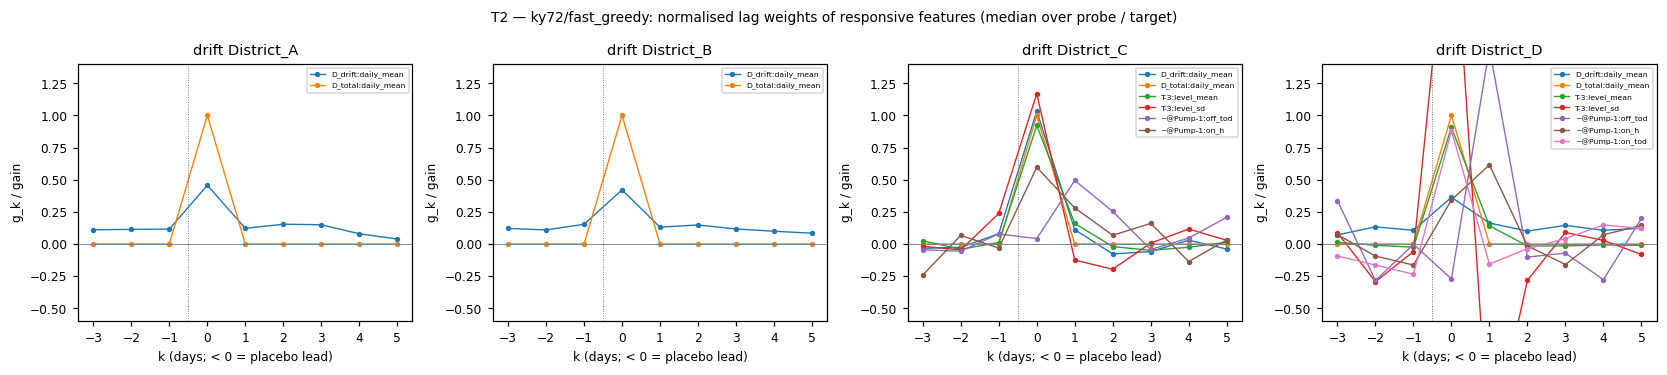

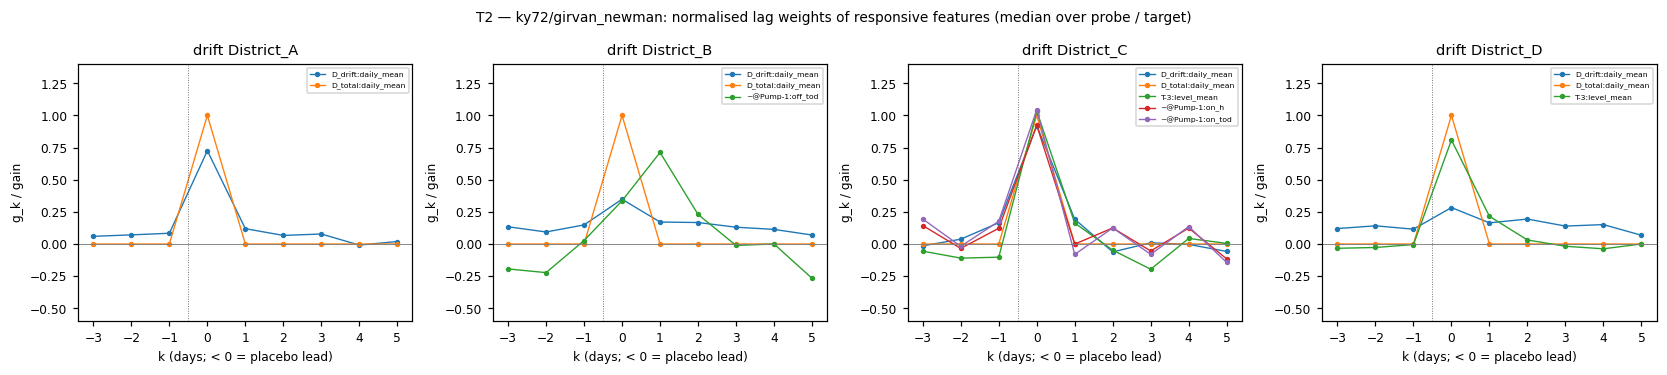

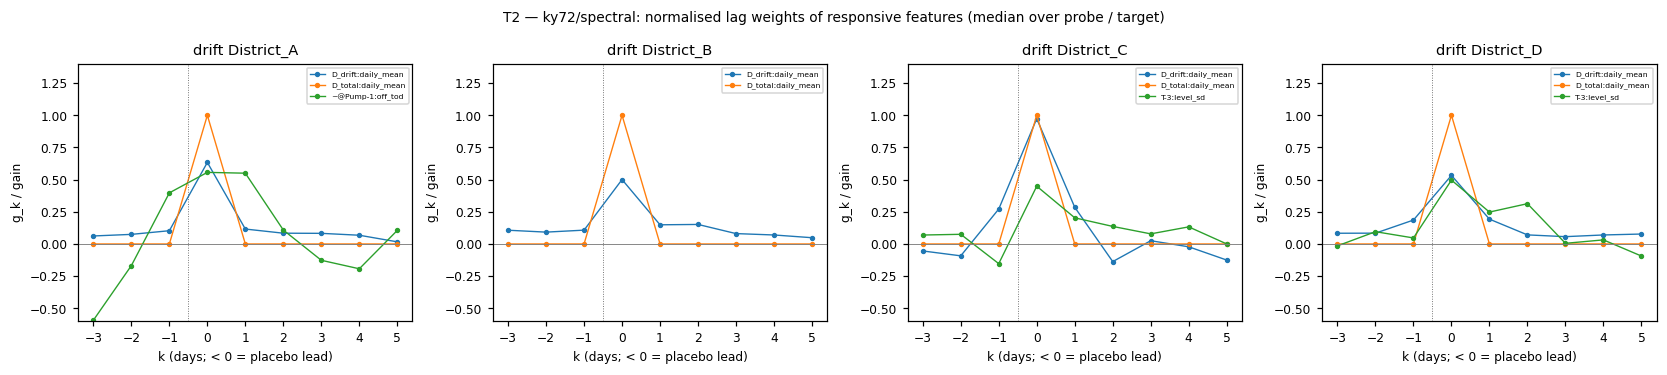

In [13]:
DL = TB["dlag"]
DL_ok = DL[DL["n_events"] > 0].copy()
STRONG_T = 4.0
display(Markdown(f"**Responsive features** (|t_gain| ≥ {STRONG_T}) — per world"))
cols = ["districting", "drift", "source", "world", "unit", "kind", "feature", "n_events", "gain",
        "t_gain", "g0_share", "centroid_d", "lead_share", "R2"]
display(DL_ok[DL_ok["t_gain"].abs() >= STRONG_T][cols]
        .sort_values(["districting", "drift", "unit", "feature", "source"]).round(3)
        .reset_index(drop=True))
display(Markdown("**Summary by kind of unit** — responsive features only"))
display(DL_ok[DL_ok["t_gain"].abs() >= STRONG_T]
        .groupby(["districting", "kind", "feature"])
        .agg(n=("unit", "size"), g0_share=("g0_share", "median"),
             centroid_d=("centroid_d", "median"), lead_share=("lead_share", "median"))
        .round(3))

DG = TB["dlag_g"]
DG = DG[DG["t_gain"].abs() >= STRONG_T]
for (net, meth), g in DG.groupby(["network", "districting"]):
    drifts = sorted(g["drift"].unique())
    fig, axes = plt.subplots(1, len(drifts), figsize=(3.8 * len(drifts), 3.4), squeeze=False)
    for ax, dr in zip(axes[0], drifts):
        h = g[g["drift"] == dr]
        for (unit, feat), q in h.groupby(["unit", "feature"]):
            q = q.groupby("k_d")["g_norm"].median()
            ax.plot(q.index, q.values, marker="o", ms=2.5, lw=0.9, label=f"{unit}:{feat}")
        ax.axvline(-0.5, color="0.4", lw=0.6, ls=":"); ax.axhline(0, color="0.5", lw=0.6)
        ax.set(title=f"drift {dr}", xlabel="k (days; < 0 = placebo lead)",
               ylabel="g_k / gain", ylim=(-0.6, 1.4))
        ax.legend(fontsize=5)
    fig.suptitle(f"T2 — {net}/{meth}: normalised lag weights of responsive features "
                 "(median over probe / target)", fontsize=9)
    fig.tight_layout(); plt.show()

### B1 — demand / storage decomposition over the transition span

Per world, over the transition span (one month before the first switch to the start of the settled
window), **hourly raw** flow of every flow gauge (pump links excluded), three nested least-squares fits
with an intercept: demand only ($D_1..D_K$), storage only (each pump's flow and each tank's net inflow),
and both; adjusted $R^2$.

$$U_s=R^2_{\text{full}}-R^2_{\text{dem}}\quad\text{(what storage explains that district demand cannot)}$$

**Classification revised.** Pump and tank flows are the districts' boundary inflows, so by mass balance
the storage regressors can reproduce district demand: on D-Town $U_d=R^2_{\text{full}}-R^2_{\text{sto}}$ is
exactly 0 for every link, and the old rule $U_s>U_d$ called anything with $U_s>0$ storage. The quantities
that stay meaningful are $R^2_{\text{dem}}$ (how much district demand explains) and $U_s$. The class is
`storage` if $U_s>R^2_{\text{dem}}$ — storage adds more than demand explains in total — else `demand`;
a comparison of two shares, no tuned threshold. $U_d$ is still shown, but read it only on a single-hub
network.

In [14]:
DC = TB["decomp"]
GB = (DC.groupby(["network", "districting", "id", "element", "home", "tier", "placed"])
      [["R2_dem", "R2_sto", "R2_full", "U_d", "U_s", "shared", "phi"]].median().reset_index())
GB["storage"] = GB["U_s"] > GB["R2_dem"]
display(Markdown("**By tier** — medians over gauges"))
display(GB.groupby(["districting", "tier"])
        .agg(n=("id", "size"), R2_dem=("R2_dem", "median"), R2_sto=("R2_sto", "median"),
             R2_full=("R2_full", "median"), U_d=("U_d", "median"), U_s=("U_s", "median"),
             shared=("shared", "median"), phi=("phi", "median"),
             storage_share=("storage", "mean"))
        .round(3))
display(Markdown("**Placed gauges**"))
display(GB[GB["placed"] != ""].sort_values(["districting", "placed", "home"]).round(3)
        .reset_index(drop=True))

**By tier** — medians over gauges

n  R2_dem  R2_sto  R2_full    U_d    U_s  shared    phi  storage_share
districting   tier                                                                                
fast_greedy   core        229   0.944   0.573    0.963  0.340  0.000   0.520  0.000          0.004
              foreign      91   0.168   0.974    1.000  0.025  0.832   0.145  0.427          0.945
              transition  283   0.117   0.966    0.998  0.029  0.878   0.082  0.367          0.859
girvan_newman core        253   0.934   0.594    0.964  0.293  0.000   0.566  0.000          0.051
              foreign      61   0.194   0.986    0.999  0.012  0.796   0.174  0.427          0.951
              transition  289   0.228   0.972    0.998  0.023  0.766   0.164  0.417          0.862
spectral      core        241   0.930   0.751    0.953  0.160 -0.000   0.740  0.000          0.017
              foreign      55   0.210   0.994    1.000  0.005  0.789   0.207  0.401          0.855
              transition  307   0.173   0.987    0.998  0.008  0.816   0.143  0.401          0.899

**Placed gauges**

,network,districting,id,element,home,tier,placed,R2_dem,R2_sto,R2_full,U_d,U_s,shared,phi,storage
0,ky72,fast_greedy,q_P-191,P-191,District_A,transition,mixed,0.566,0.690,0.958,0.265,0.385,0.311,0.415,False
1,ky72,fast_greedy,q_P-288,P-288,District_A,transition,mixed,0.277,0.957,0.998,0.040,0.721,0.241,0.481,True
2,ky72,fast_greedy,q_P-164,P-164,District_B,transition,mixed,0.242,0.937,0.996,0.058,0.755,0.207,0.429,True
3,ky72,fast_greedy,q_P-617,P-617,District_B,transition,mixed,0.290,0.916,0.993,0.071,0.703,0.242,0.477,True
4,ky72,fast_greedy,q_P-10,P-10,District_C,transition,mixed,0.426,0.992,0.999,0.007,0.573,0.422,0.442,True
5,ky72,fast_greedy,q_P-267,P-267,District_C,transition,mixed,0.177,0.951,0.998,0.047,0.821,0.138,0.405,True
6,ky72,fast_greedy,q_P-246,P-246,District_D,transition,mixed,0.184,0.988,1.000,0.011,0.816,0.173,0.498,True
7,ky72,fast_greedy,q_P-537,P-537,District_D,transition,mixed,0.397,0.959,0.984,0.022,0.587,0.369,0.369,True
8,ky72,fast_greedy,q_P-467,P-467,District_A,core,pure,0.980,0.367,0.980,0.529,0.000,0.367,0.000,False
9,ky72,fast_greedy,q_P-499,P-499,District_A,core,pure,0.987,0.374,0.987,0.525,-0.000,0.374,0.000,False


### B2 — partition invariance

Whether a link sits on a storage path should not depend on the partition. For every link present in two
partitions, threshold-free rank correlations of $U_s$ and of $R^2_{\text{dem}}$ across the pair, and the
agreement / Cohen's $\kappa$ of the class ($U_s>R^2_{\text{dem}}$), next to the agreement of the current
purity tier — the baseline the new class should beat. **Needs at least two partitions in the study.**

In [15]:
print("partitions in this study:", list(GB["districting"].unique()))

partitions in this study: ['fast_greedy', 'girvan_newman', 'spectral']


,pair,n_links,spearman_Us,spearman_R2dem,class_agree,kappa,storage_a,storage_b,tier_agree
0,fast_greedy vs girvan_newman,600,0.941,0.959,0.972,0.943,0.550,0.532,0.720
1,fast_greedy vs spectral,600,0.958,0.977,0.985,0.970,0.550,0.545,0.788
2,girvan_newman vs spectral,600,0.959,0.976,0.987,0.973,0.532,0.545,0.795


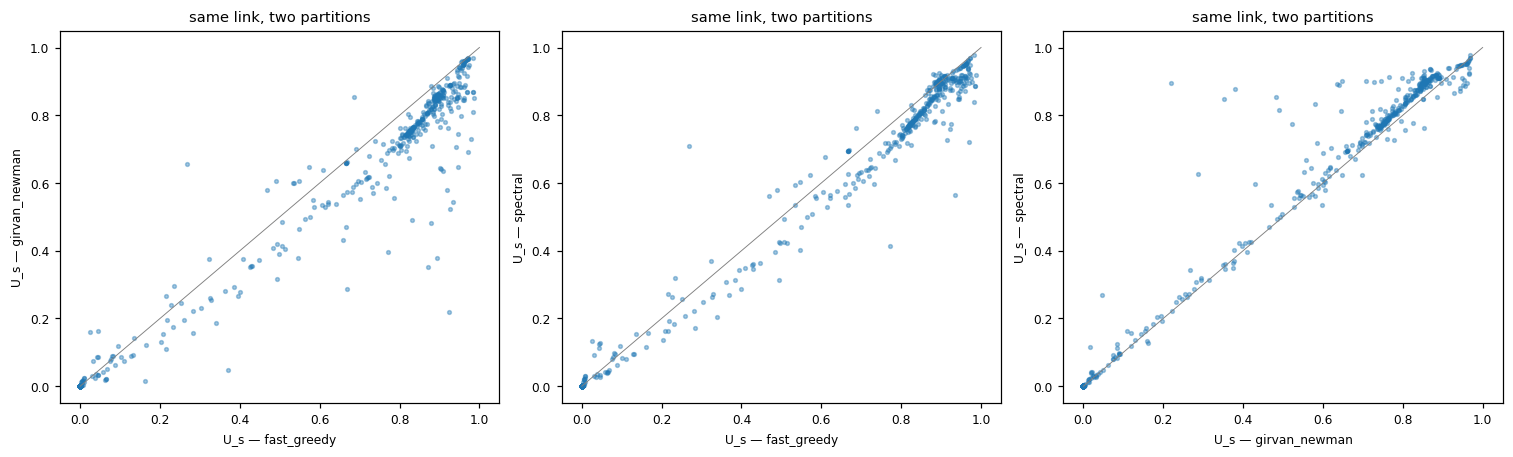

In [16]:
from itertools import combinations
meths = sorted(GB["districting"].unique())
if len(meths) < 2:
    print(f"B2 needs at least two partitions; this study has {meths}.")
else:
    WIDE = GB.pivot_table(index=["network", "element"], columns="districting",
                          values=["U_s", "R2_dem"])
    CLS = GB.pivot_table(index=["network", "element"], columns="districting", values="storage",
                         aggfunc="first")
    TIER = GB.pivot_table(index=["network", "element"], columns="districting", values="tier",
                          aggfunc="first")
    rows = []
    for a, b in combinations(meths, 2):
        m = WIDE[[("U_s", a), ("U_s", b), ("R2_dem", a), ("R2_dem", b)]].dropna()
        c = CLS.loc[m.index, [a, b]].astype(int)
        po = float((c[a] == c[b]).mean())
        pe = float(c[a].mean() * c[b].mean() + (1 - c[a].mean()) * (1 - c[b].mean()))
        t = TIER.loc[m.index, [a, b]].dropna()
        rows.append({"pair": f"{a} vs {b}", "n_links": len(m),
                     "spearman_Us": m[("U_s", a)].rank().corr(m[("U_s", b)].rank()),
                     "spearman_R2dem": m[("R2_dem", a)].rank().corr(m[("R2_dem", b)].rank()),
                     "class_agree": po, "kappa": (po - pe) / (1 - pe) if pe < 1 else np.nan,
                     "storage_a": c[a].mean(), "storage_b": c[b].mean(),
                     "tier_agree": float((t[a] == t[b]).mean())})
    display(pd.DataFrame(rows).round(3))
    pairs = list(combinations(meths, 2))
    fig, axes = plt.subplots(1, len(pairs), figsize=(4.6 * len(pairs), 4.2), squeeze=False)
    for ax, (a, b) in zip(axes[0], pairs):
        m = WIDE[[("U_s", a), ("U_s", b)]].dropna()
        ax.scatter(m[("U_s", a)], m[("U_s", b)], s=6, alpha=0.4)
        ax.plot([0, 1], [0, 1], color="0.5", lw=0.6)
        ax.set(xlabel=f"U_s — {a}", ylabel=f"U_s — {b}", title="same link, two partitions")
    fig.tight_layout(); plt.show()

### B3 — independent indicators

The decomposition is a linear fit; three quantities that do not come from it should agree with it:
A3's event lift, now per pump (non-linear: are the gauge's abrupt changes events of one pump), `phi` (sign alternation over
the transition span), and the link's hop distance to the nearest storage hub (every active tank and every active pump's end
nodes — topology only, no flows). Spearman per partition, and the indicators by tier.

| column | expected sign if $U_s$ measures storage linkage |
|---|---|
| `rho_Us_lift` | + |
| `rho_Us_phi` | + |
| `rho_Us_dist` | − (closer to the hub, more storage) |

,districting,n,rho_Us_lift,rho_Us_phi,rho_Us_dist
0,fast_greedy,603,0.835,0.616,-0.125
1,girvan_newman,603,0.830,0.643,-0.158
2,spectral,603,0.846,0.665,-0.138


U_s  R2_dem   lift    phi  hub_dist
districting   tier                                             
fast_greedy   core        0.000   0.944  0.918  0.000      15.0
              foreign     0.832   0.168  4.031  0.427      12.0
              transition  0.878   0.117  4.031  0.367      15.0
girvan_newman core        0.000   0.934  0.319  0.000      16.0
              foreign     0.796   0.194  4.031  0.427      14.0
              transition  0.766   0.228  4.031  0.417      14.0
spectral      core       -0.000   0.930  0.542  0.000      16.0
              foreign     0.789   0.210  4.031  0.401      13.0
              transition  0.816   0.173  4.031  0.401      14.0

**By class** (`storage` = U_s > R2_dem)

n    U_s  R2_dem   lift    phi  hub_dist
districting   storage                                            
fast_greedy   False    273  0.000   0.932  0.958  0.000      15.0
              True     330  0.873   0.121  4.031  0.427      14.0
girvan_newman False    283  0.000   0.930  0.333  0.000      15.0
              True     320  0.796   0.196  4.031  0.427      14.0
spectral      False    276  0.000   0.923  0.558  0.000      15.0
              True     327  0.836   0.154  4.031  0.401      14.0

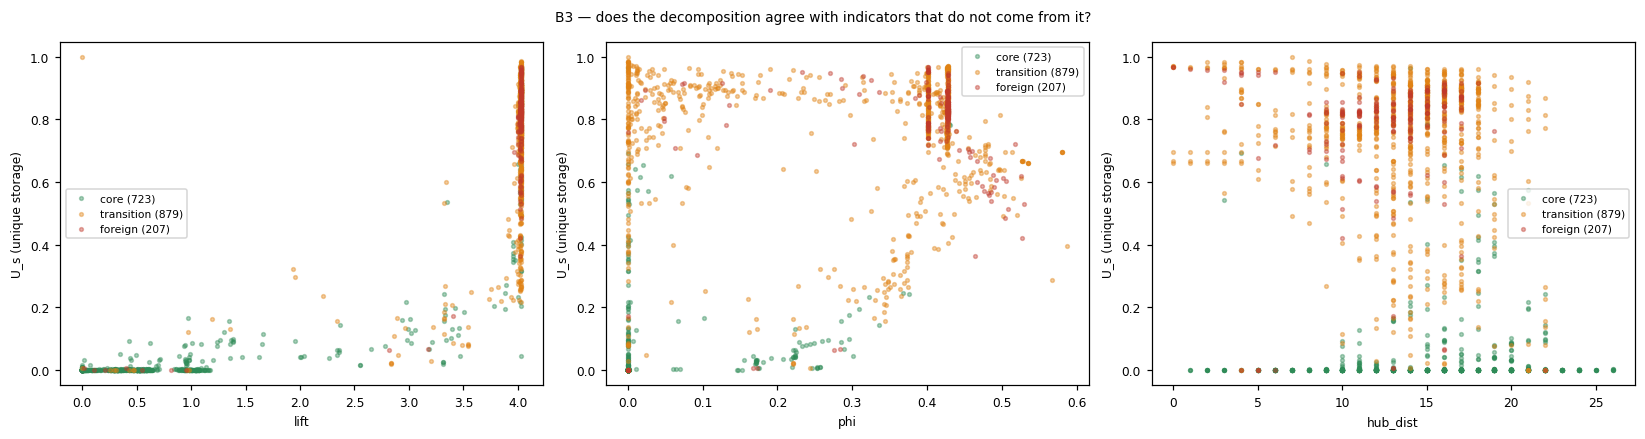

In [17]:
LIFT = (A["event"].groupby(["districting", "id"])["lift"].median().rename("lift").reset_index()
        if "A" in globals() and len(A.get("event", [])) else pd.DataFrame(columns=["districting", "id", "lift"]))
B3 = GB.merge(LIFT, on=["districting", "id"], how="left")
B3["hub_dist"] = [hubdist.get(n, {}).get(e, np.nan) for n, e in zip(B3["network"], B3["element"])]
rows = []
for meth, g in B3.groupby("districting"):
    r = lambda x: g["U_s"].rank().corr(g[x].rank()) if g[x].notna().sum() > 3 else np.nan
    rows.append({"districting": meth, "n": len(g), "rho_Us_lift": r("lift"),
                 "rho_Us_phi": r("phi"), "rho_Us_dist": r("hub_dist")})
display(pd.DataFrame(rows).round(3))
display(B3.groupby(["districting", "tier"])
        [["U_s", "R2_dem", "lift", "phi", "hub_dist"]].median().round(3))
display(Markdown("**By class** (`storage` = U_s > R2_dem)"))
display(B3.groupby(["districting", "storage"])
        .agg(n=("id", "size"), U_s=("U_s", "median"), R2_dem=("R2_dem", "median"),
             lift=("lift", "median"), phi=("phi", "median"), hub_dist=("hub_dist", "median"))
        .round(3))
fig, axes = plt.subplots(1, 3, figsize=(15, 4.0))
for ax, x in zip(axes, ("lift", "phi", "hub_dist")):
    for tier, colour in TIER_COLOUR.items():
        g = B3[B3["tier"] == tier]
        if len(g):
            ax.scatter(g[x], g["U_s"], s=6, alpha=0.4, c=colour, label=f"{tier} ({len(g)})")
    ax.set(xlabel=x, ylabel="U_s (unique storage)")
    ax.legend(fontsize=7)
fig.suptitle("B3 — does the decomposition agree with indicators that do not come from it?", fontsize=9)
fig.tight_layout(); plt.show()

### B4 — where would class boundaries go

Distributions only. The class line is $U_s=R^2_{\text{dem}}$ (the diagonal of the scatter); what matters is
whether links sit far from it on both sides (a clean split) or crowd along it (a continuum, where any
boundary is a choice to justify and a **hybrid** class may be the honest third category).

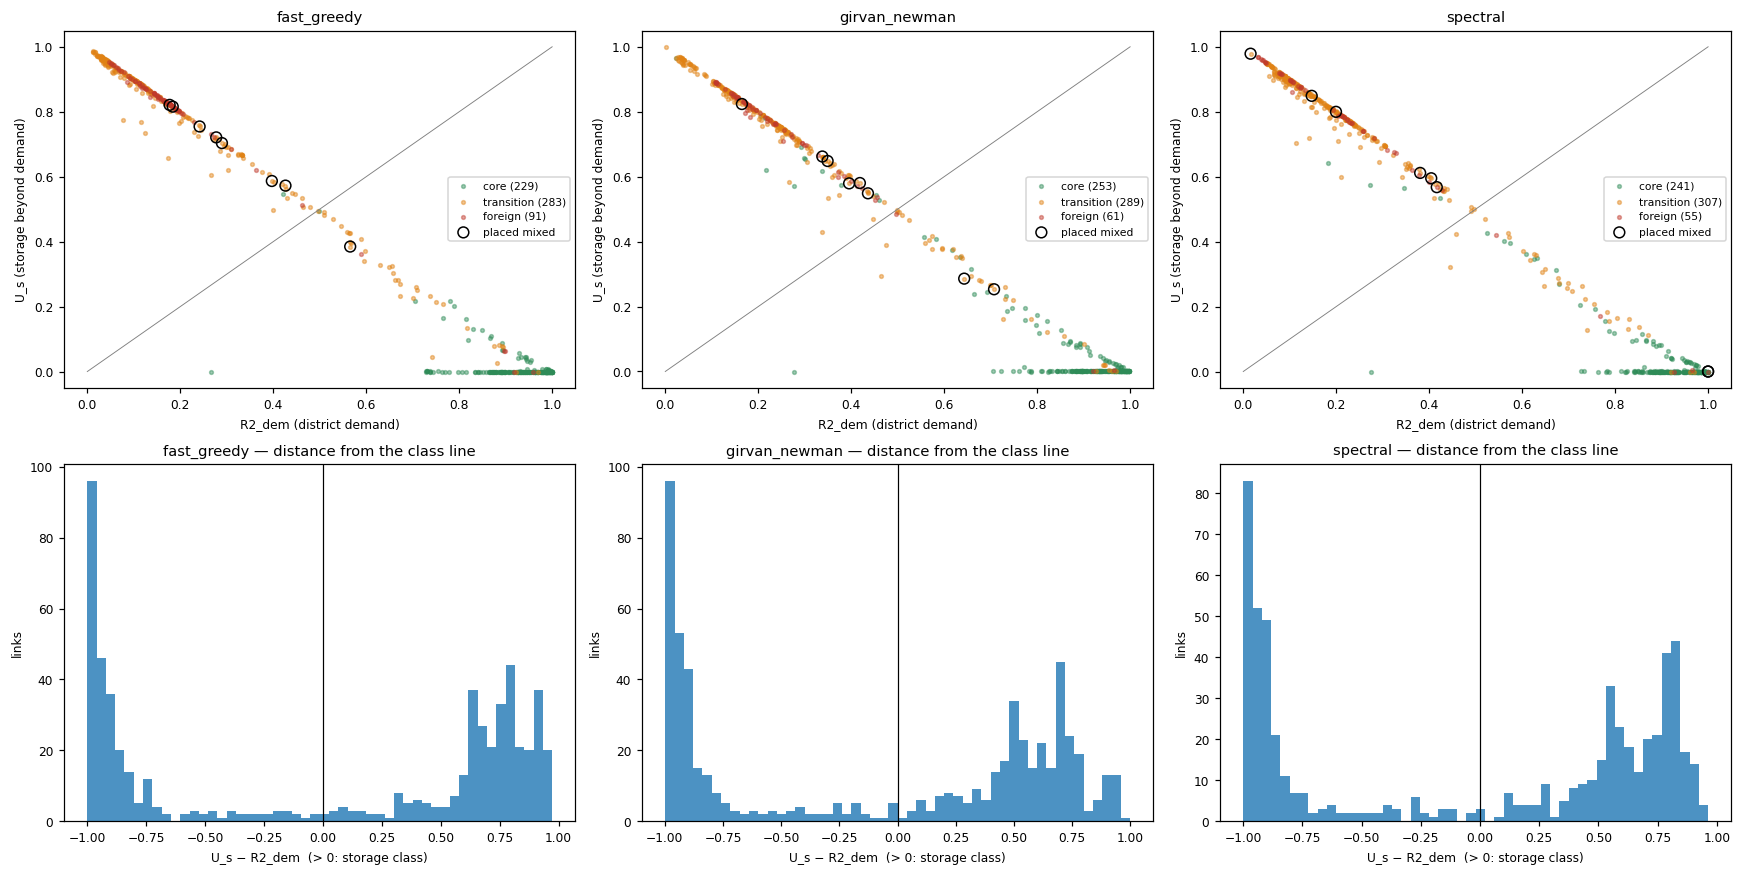

,n,storage_share,near_line,U_s_med,R2_dem_med
districting,,,,,
fast_greedy,603,0.547,0.045,0.675,0.301
girvan_newman,603,0.531,0.056,0.580,0.389
spectral,603,0.542,0.045,0.624,0.352


near_line: share of links with |U_s - R2_dem| < 0.2 — a descriptive band, not a class threshold


In [18]:
parts = sorted(GB["districting"].unique())
fig, axes = plt.subplots(2, len(parts), figsize=(5.3 * len(parts), 8.0), squeeze=False)
for c, meth in enumerate(parts):
    g = GB[GB["districting"] == meth]
    ax = axes[0][c]
    for tier, colour in TIER_COLOUR.items():
        h = g[g["tier"] == tier]
        if len(h):
            ax.scatter(h["R2_dem"], h["U_s"], s=6, alpha=0.45, c=colour, label=f"{tier} ({len(h)})")
    pm = g[g["placed"].str.contains("mixed")]
    ax.scatter(pm["R2_dem"], pm["U_s"], s=50, facecolors="none", edgecolors="k", label="placed mixed")
    ax.plot([0, 1], [0, 1], color="0.5", lw=0.6)
    ax.set(xlabel="R2_dem (district demand)", ylabel="U_s (storage beyond demand)", title=meth)
    ax.legend(fontsize=7)
    ax = axes[1][c]
    ax.hist(g["U_s"] - g["R2_dem"], bins=50, alpha=0.8)
    ax.axvline(0, color="k", lw=0.8)
    ax.set(xlabel="U_s − R2_dem  (> 0: storage class)", ylabel="links",
           title=f"{meth} — distance from the class line")
fig.tight_layout(); plt.show()
display(GB.groupby("districting")
        .agg(n=("id", "size"), storage_share=("storage", "mean"),
             near_line=("U_s", lambda s: float(((s - GB.loc[s.index, "R2_dem"]).abs() < 0.2).mean())),
             U_s_med=("U_s", "median"), R2_dem_med=("R2_dem", "median"))
        .round(3))
print("near_line: share of links with |U_s - R2_dem| < 0.2 — a descriptive band, not a class threshold")